<a href="https://colab.research.google.com/github/Nishkam11/Jovian-ML-Project/blob/main/MagNet_DST_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MagNet DST Prediction Challenge

## Problem Overview
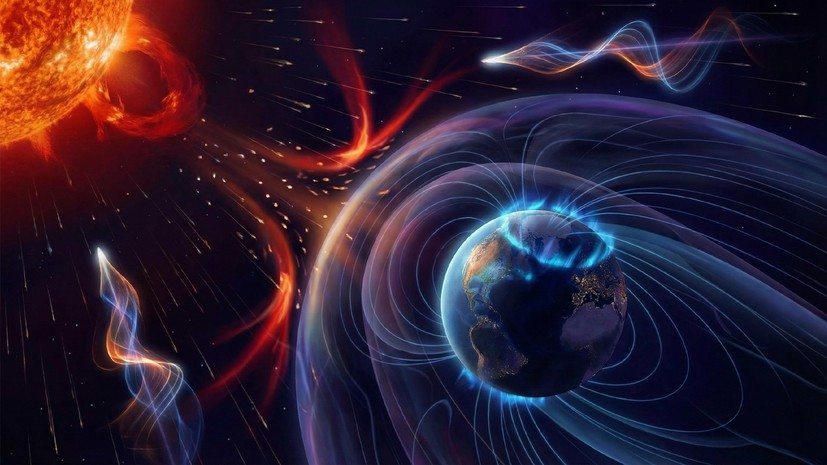

The objective of the MagNet DST Prediction challenge was to build machine learning models capable of forecasting the **Dst (Disturbance Storm Time) index**, which is an important indicator of geomagnetic storm activity.

The challenge focused on improving prediction performance while maintaining practical constraints required for real-time space weather forecasting systems.

The main goals were:

1. **Improve predictive accuracy** by developing models that can forecast:

   * Current Dst value (**t0**)
   * Dst value one hour ahead (**t1**)

2. **Maintain operational feasibility** by ensuring the models can run under real-time simulation constraints with limited runtime and input requirements.

3. **Use real-time solar wind observations** as input features, similar to the data available in operational space weather monitoring systems.

This is a challenging forecasting problem because the relationship between solar wind conditions and geomagnetic disturbances is complex, and the best modeling approach is not known beforehand.

In this project, different feature engineering techniques and machine learning approaches were explored to improve Dst prediction performance using solar wind and related space weather data.

Dataset source:
https://www.kaggle.com/datasets/kingabzpro/magnet-nasa


#### Project Outline

1. Download the Dataset
2. Explore and Analyze the Data
3. Feature Engineering & Merging
4. Create required Target Features to complete the features set
5. Prepare Dataset for Training
6. Train Hardcoded & Baseline Models
7. Make Predictions and Submit
8. New Features
9. Train & Evaluate Different Models
10. Tune Hyperparameters


## 1. Download the Dataset

- Install required libraries
- Download data from Kaggle
- View dataset files
- Load training set with Pandas
- Load test set with Pandas


### Install and Import required libraries

In [ ]:
!pip install opendatasets -q

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_url = 'https://www.kaggle.com/datasets/kingabzpro/magnet-nasa'

### Download data from Kaggle

In [ ]:
%%time
od.download(dataset_url)

Skipping, found downloaded files in "./magnet-nasa" (use force=True to force download)
CPU times: user 783 µs, sys: 0 ns, total: 783 µs
Wall time: 908 µs


In [ ]:
data_dir = './magnet-nasa'

### View Dataset files

In [ ]:
# List of files with size
!ls -lh {data_dir}

total 879M
-rw-r--r-- 1 root root 4.0M Jun 14 11:34 dst_labels.csv
-rw-r--r-- 1 root root 303K Jun 14 11:34 satellite_positions.csv
-rw-r--r-- 1 root root 874M Jun 14 11:34 solar_wind.csv
-rw-r--r-- 1 root root 6.0K Jun 14 11:34 sunspots.csv


In [ ]:
!head {data_dir}/solar_wind.csv
!head {data_dir}/satellite_positions.csv
!head {data_dir}/sunspots.csv
!head {data_dir}/dst_labels.csv

period,timedelta,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,source
train_a,0 days 00:00:00,-5.55,3.0,1.25,11.09,153.37,-5.55,3.0,1.25,11.09,153.37,6.8,1.53,383.92,110237.0,ac
train_a,0 days 00:01:00,-5.58,3.16,1.17,10.1,151.91,-5.58,3.16,1.17,10.1,151.91,6.83,1.69,381.79,123825.0,ac
train_a,0 days 00:02:00,-5.15,3.66,0.85,7.87,146.04,-5.15,3.66,0.85,7.87,146.04,6.77,1.97,389.11,82548.0,ac
train_a,0 days 00:03:00,-5.2,3.68,0.68,6.17,146.17,-5.2,3.68,0.68,6.17,146.17,6.74,1.97,389.11,82548.0,ac
train_a,0 days 00:04:00,-5.12,3.68,0.49,4.62,145.72,-5.12,3.68,0.49,4.62,145.72,6.65,1.77,384.26,94269.0,ac
train_a,0 days 00:05:00,-4.78,3.86,0.05,0.8,142.47,-4.78,3.86,0.05,0.8,142.47,6.54,0.93,367.98,28227.0,ac
train_a,0 days 00:06:00,-5.15,3.53,0.52,4.8,147.06,-5.15,3.53,0.52,4.8,147.06,6.63,1.74,384.72,87302.0,ac
train_a,0 days 00:07:00,-5.35,3.06,1.21,10.81,152.06,-5.35,3.06,1.21,10.81,152.06,6.65,1.7,382.41,101225.0,ac
train_a,

In [ ]:
# No. of lines in training set
!wc -l {data_dir}/solar_wind.csv
!wc -l {data_dir}/satellite_positions.csv
!wc -l {data_dir}/sunspots.csv
!wc -l {data_dir}/dst_labels.csv

8392321 ./magnet-nasa/solar_wind.csv
5829 ./magnet-nasa/satellite_positions.csv
193 ./magnet-nasa/sunspots.csv
139873 ./magnet-nasa/dst_labels.csv


#### Observation

* All files contain `period` and `timedelta` as common columns, which together act as a **compound key** for uniquely identifying records across the datasets.

* `period`: This column contains 3 unique values: `train_a`, `train_b`, and `train_c`, representing three different time-series data sequences.

* `timedelta`: This column represents the elapsed time intervals from the start of each series at which the observations were recorded.

**Note:** These columns can be converted into a pandas **MultiIndex** to preserve the time-series structure and improve data alignment during analysis and modeling.


### Load training set with Pandas

In [ ]:
def PeriodTime_to_index(df):
  df.timedelta = pd.to_timedelta(df.timedelta)
  df.set_index(["period", "timedelta"], inplace=True)

In [ ]:
import pandas as pd
import numpy as np

solar_wind = pd.read_csv('/content/magnet-nasa/solar_wind.csv')
PeriodTime_to_index(solar_wind)
solar_wind.head()

bx_gse  by_gse  bz_gse  theta_gse  phi_gse  bx_gsm  \
period  timedelta                                                             
train_a 0 days 00:00:00   -5.55    3.00    1.25      11.09   153.37   -5.55   
        0 days 00:01:00   -5.58    3.16    1.17      10.10   151.91   -5.58   
        0 days 00:02:00   -5.15    3.66    0.85       7.87   146.04   -5.15   
        0 days 00:03:00   -5.20    3.68    0.68       6.17   146.17   -5.20   
        0 days 00:04:00   -5.12    3.68    0.49       4.62   145.72   -5.12   

                         by_gsm  bz_gsm  theta_gsm  phi_gsm    bt  density  \
period  timedelta                                                            
train_a 0 days 00:00:00    3.00    1.25      11.09   153.37  6.80     1.53   
        0 days 00:01:00    3.16    1.17      10.10   151.91  6.83     1.69   
        0 days 00:02:00    3.66    0.85       7.87   146.04  6.77     1.97   
        0 days 00:03:00    3.68    0.68       6.17   146.17  6.74     1.97   
        0 days 00:04:00    3.68    0.49       4.62   145.72  6.65     1.77   

                          speed  temperature source  
period  timedelta                                    
train_a 0 days 00:00:00  383.92     110237.0     ac  
        0 days 00:01:00  381.79     123825.0     ac  
        0 days 00:02:00  389.11      82548.0     ac  
        0 days 00:03:00  389.11      82548.0     ac  
        0 days 00:04:00  384.26      94269.0     ac

In [ ]:
import pandas as pd
import numpy as np

satellite_positions = pd.read_csv('/content/magnet-nasa/satellite_positions.csv')
PeriodTime_to_index(satellite_positions)

satellite_positions.head()

gse_x_ace  gse_y_ace  gse_z_ace  gse_x_dscovr  \
period  timedelta                                                  
train_a 0 days     1522376.9   143704.6   149496.7           NaN   
        1 days     1525410.9   136108.8   151034.1           NaN   
        2 days     1528484.9   128470.5   152387.7           NaN   
        3 days     1531570.3   120818.4   153561.4           NaN   
        4 days     1534633.1   113178.5   154534.6           NaN   

                   gse_y_dscovr  gse_z_dscovr  
period  timedelta                              
train_a 0 days              NaN           NaN  
        1 days              NaN           NaN  
        2 days              NaN           NaN  
        3 days              NaN           NaN  
        4 days              NaN           NaN

In [ ]:
sunspots = pd.read_csv('/content/magnet-nasa/sunspots.csv')
PeriodTime_to_index(sunspots)
sunspots.head()

smoothed_ssn
period  timedelta              
train_a 0 days             65.4
        13 days            72.0
        44 days            76.9
        74 days            80.8
        105 days           85.4

In [ ]:
dst_labels = pd.read_csv('/content/magnet-nasa/dst_labels.csv')
PeriodTime_to_index(dst_labels)
dst_labels.head()

dst
period  timedelta           
train_a 0 days 00:00:00   -7
        0 days 01:00:00  -10
        0 days 02:00:00  -10
        0 days 03:00:00   -6
        0 days 04:00:00   -2

### Load Test Set with Pandas

The test dataset is obtained from NOAA's NGDC geomagnetic data archive:

https://www.ngdc.noaa.gov/geomag/data/geomag/magnet/private.zip

This dataset was used as the **private test dataset** in the 2021 MagNet competition. In this project, it is used as a **validation/test set** to evaluate the performance of trained models on unseen data.

Similar to the training dataset, it contains the following four files:

* `dst_labels.csv`
* `satellite_positions.csv`
* `solar_wind.csv`
* `sunspots.csv`

**Note:** The `dst_labels.csv` file is provided with the test dataset and serves as the ground truth for comparing and evaluating the generated Dst predictions.


In [ ]:
import os
if not os.path.exists('private'):
  !wget -O private.zip https://www.ngdc.noaa.gov/geomag/data/geomag/magnet/private.zip
  !unzip -q private.zip
  !ls private

In [ ]:
private_data_dir = '/content/private'

In [ ]:
!ls -lh {private_data_dir}

total 370M
-rw-r--r-- 1 root root 1.6M Dec 13  2020 dst_labels.csv
-rw-r--r-- 1 root root 126K Dec 13  2020 satellite_positions.csv
-rw-r--r-- 1 root root 368M Dec 14  2020 solar_wind.csv
-rw-r--r-- 1 root root 2.4K Dec 13  2020 sunspots.csv


In [ ]:
print("Loading solar_wind_test.csv...", end='\t')
solar_wind_test = pd.read_csv(f'{private_data_dir}/solar_wind.csv')
PeriodTime_to_index(solar_wind_test)
print("Done!")

print("Loading satellite_positions_test.csv...", end='\t')
satellite_positions_test = pd.read_csv(f'{private_data_dir}/satellite_positions.csv')
PeriodTime_to_index(satellite_positions_test)
print("Done!")

print("Loading sunspots_test.csv...", end='\t')
sunspots_test = pd.read_csv(f'{private_data_dir}/sunspots.csv')
PeriodTime_to_index(sunspots_test)
print("Done!")

print("Loading dst_labels_test.csv...", end='\t')
dst_labels_test = pd.read_csv(f'{private_data_dir}/dst_labels.csv')
PeriodTime_to_index(dst_labels_test)
print("Done!")

print("\nPrivate Test DataFrames Loaded Successfully:")
print(f"solar_wind_test shape: {solar_wind_test.shape}")
print(f"satellite_positions_test shape: {satellite_positions_test.shape}")
print(f"sunspots_test shape: {sunspots_test.shape}")
print(f"dst_labels_test shape: {dst_labels_test.shape}")

Loading solar_wind_test.csv...	Done!
Loading satellite_positions_test.csv...	Done!
Loading sunspots_test.csv...	Done!
Loading dst_labels_test.csv...	Done!

Private Test DataFrames Loaded Successfully:
solar_wind_test shape: (3551040, 15)
satellite_positions_test shape: (2466, 6)
sunspots_test shape: (81, 1)
dst_labels_test shape: (59184, 1)


In [ ]:
solar_wind_test.head()

bx_gse  by_gse  bz_gse  theta_gse  phi_gse  bx_gsm  \
period timedelta                                                             
test_a 0 days 00:00:00   -3.35    3.44   -1.01     -11.91   134.18   -3.35   
       0 days 00:01:00   -2.98    3.59   -1.04     -12.52   129.71   -2.98   
       0 days 00:02:00   -3.29    3.46   -1.04     -12.33   133.54   -3.29   
       0 days 00:03:00   -3.39    3.44   -0.79      -9.29   134.57   -3.39   
       0 days 00:04:00   -3.28    3.52   -0.86     -10.13   132.99   -3.28   

                        by_gsm  bz_gsm  theta_gsm  phi_gsm    bt  density  \
period timedelta                                                            
test_a 0 days 00:00:00    3.59    0.14       1.65   133.00  4.91     5.57   
       0 days 00:01:00    3.73    0.17       1.98   128.61  4.78     5.66   
       0 days 00:02:00    3.62    0.12       1.34   132.29  4.89     4.95   
       0 days 00:03:00    3.51    0.35       4.09   133.97  4.89     4.96   
       0 days 00:04:00    3.61    0.31       3.59   132.26  4.88     5.35   

                         speed  temperature source  
period timedelta                                    
test_a 0 days 00:00:00  338.59      41313.0     ac  
       0 days 00:01:00  339.11      37388.0     ac  
       0 days 00:02:00  337.70      35715.0     ac  
       0 days 00:03:00  338.41      38214.0     ac  
       0 days 00:04:00  336.63      40458.0     ac

#### Observations about the `solar_wind` Data

* The `solar_wind` dataset provides the primary input features for this supervised learning regression problem, while the target variable (`dst`) is provided in the `dst_labels` dataset.

* The `solar_wind` dataset is approximately **874 MB** in size and contains around **8.4 million rows**.

* It contains **17 columns**, including:

  * Temporal alignment columns: `period`, `timedelta`
  * Magnetic field features: `bx_gse`, `by_gse`, `bz_gse`, `theta_gse`, `phi_gse`, `bx_gsm`, `by_gsm`, `bz_gsm`, `theta_gsm`, `phi_gsm`, `bt`
  * Plasma parameters: `density`, `speed`, `temperature`
  * Additional metadata: `source`

* The `solar_wind` dataset does not contain the target variable (`dst`). It needs to be merged with the `dst_labels` dataset using temporal information (`period` and `timedelta`) before model training.

* The test dataset follows the same structure as the training dataset, allowing the same preprocessing, feature engineering, and merging pipeline to be applied consistently during evaluation and prediction.

* Due to the large size of the dataset, efficient memory management and optimized data-processing techniques are required during model development.

**Note:** The Disturbance Storm Time (`Dst`) index is a measure of geomagnetic storm activity. It represents changes in Earth's magnetic field, particularly the decrease in the horizontal component near the magnetic equator, and is widely used as an indicator of geomagnetic disturbances.


## 2. Explore and Analyze the Data

* Basic info about train set
* Basic info about test set
* Exploratory Data Analysis & visualization
* Ask & Answer Questions


### Train Set

In [ ]:
solar_wind.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8392320 entries, ('train_a', Timedelta('0 days 00:00:00')) to ('train_c', Timedelta('2435 days 23:59:00'))
Data columns (total 15 columns):
 #   Column       Dtype  
---  ------       -----  
 0   bx_gse       float64
 1   by_gse       float64
 2   bz_gse       float64
 3   theta_gse    float64
 4   phi_gse      float64
 5   bx_gsm       float64
 6   by_gsm       float64
 7   bz_gsm       float64
 8   theta_gsm    float64
 9   phi_gsm      float64
 10  bt           float64
 11  density      float64
 12  speed        float64
 13  temperature  float64
 14  source       object 
dtypes: float64(14), object(1)
memory usage: 1.1+ GB


In [ ]:
solar_wind.describe()

,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
count,8.066432e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.065932e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.065932e+06,8.066432e+06,7.707430e+06,7.702765e+06,7.580552e+06
mean,-6.610167e-01,1.097871e-01,-2.274231e-02,1.545628e-01,1.941759e+02,-6.608663e-01,8.842110e-02,-2.912843e-02,1.967691e-01,1.943712e+02,5.606227e+00,4.421726e+00,4.305854e+02,1.150968e+05
std,3.669730e+00,3.975340e+00,3.351972e+00,3.212916e+01,9.662813e+01,3.667605e+00,3.909885e+00,3.430580e+00,3.327889e+01,9.682818e+01,3.110002e+00,4.331911e+00,1.005777e+02,1.203120e+05
min,-5.463000e+01,-5.169000e+01,-5.500000e+01,-8.989000e+01,0.000000e+00,-5.463000e+01,-5.268000e+01,-5.569000e+01,-8.991000e+01,0.000000e+00,3.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,-3.270000e+00,-2.460000e+00,-1.700000e+00,-2.145000e+01,1.240700e+02,-3.270000e+00,-2.380000e+00,-1.800000e+00,-2.279000e+01,1.246900e+02,3.640000e+00,1.790000e+00,3.568000e+02,3.978700e+04
50%,-6.700000e-01,1.100000e-01,1.000000e-02,1.400000e-01,1.768600e+02,-6.700000e-01,8.000000e-02,0.000000e+00,6.000000e-02,1.776600e+02,4.950000e+00,3.340000e+00,4.097000e+02,7.737100e+04
75%,2.020000e+00,2.640000e+00,1.690000e+00,2.168000e+01,2.864200e+02,2.020000e+00,2.540000e+00,1.790000e+00,2.313000e+01,2.865600e+02,6.720000e+00,5.710000e+00,4.856600e+02,1.512200e+05
max,5.555000e+01,5.760000e+01,7.403000e+01,8.994000e+01,3.600000e+02,5.554000e+01,5.388000e+01,7.245000e+01,8.996000e+01,3.600000e+02,8.053000e+01,1.997000e+02,1.198490e+03,6.223700e+06


In [ ]:
satellite_positions.describe()

,gse_x_ace,gse_y_ace,gse_z_ace,gse_x_dscovr,gse_y_dscovr,gse_z_dscovr
count,5.828000e+03,5828.000000,5828.000000,1.034000e+03,1034.000000,1034.000000
mean,1.486706e+06,-1272.474434,1670.989928,1.482431e+06,-9283.227273,-7295.925532
std,5.912011e+04,179299.306669,107181.239279,6.060373e+04,184208.233451,126774.499201
min,1.383933e+06,-266912.400000,-161541.500000,1.384073e+06,-272592.000000,-188233.000000
25%,1.434582e+06,-180032.850000,-104907.525000,1.422148e+06,-192547.500000,-135000.250000
50%,1.484264e+06,-1819.100000,2203.850000,1.479391e+06,-8569.000000,-6330.000000
75%,1.540133e+06,177058.475000,108857.225000,1.535550e+06,172446.500000,120150.250000
max,1.594075e+06,267057.600000,164061.400000,1.594428e+06,259187.000000,172529.000000


In [ ]:
dst_labels.describe().T

,count,mean,std,min,25%,50%,75%,max
dst,139872.0,-11.055236,19.069327,-387.0,-18.0,-8.0,0.0,67.0


In [ ]:
sunspots.describe().T

,count,mean,std,min,25%,50%,75%,max
smoothed_ssn,192.0,58.095833,52.517753,2.2,14.15,39.0,95.125,175.2


In [ ]:
solar_wind.isna().sum().to_frame(name="count").T

,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,source
count,325888,325888,325888,325888,326388,325888,325888,325888,325888,326388,325888,684890,689555,811768,316816


In [ ]:
solar_wind.source.unique()

array(['ac', nan, 'ds'], dtype=object)

#### Observations about Training Data

* The training dataset contains **8M+ rows**.

* A significant number of missing values are present in the dataset sample and need to be handled before model training.

* The target variable `dst` ranges from approximately **-387 to 67**.

* The `smoothed_ssn` feature ranges from approximately **2.2 to 175.2**.

* No obvious outliers were observed in the feature values during initial exploration.

* The `theta` values for both `gse` and `gsm` coordinate systems range between **-90° and +90°**, while `phi` ranges from **0° to 360°**, which is consistent with spherical coordinate representation.

* After loading, the dataset occupies approximately **1.1 GB of RAM**, requiring efficient memory handling during preprocessing and modeling.

* The `source` column in the `solar_wind` dataframe is of **object** data type and contains only **two unique values**.

* Since it provides limited additional information and is unlikely to contribute significantly to model learning, it is removed to reduce data complexity and improve processing efficiency.


In [ ]:
solar_wind.drop(columns=["source"], inplace=True)

In [ ]:
solar_wind_test.drop(columns=["source"], inplace=True)

### Test Set

In [ ]:
solar_wind_test.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3551040 entries, ('test_a', Timedelta('0 days 00:00:00')) to ('test_c', Timedelta('518 days 23:59:00'))
Data columns (total 14 columns):
 #   Column       Dtype  
---  ------       -----  
 0   bx_gse       float64
 1   by_gse       float64
 2   bz_gse       float64
 3   theta_gse    float64
 4   phi_gse      float64
 5   bx_gsm       float64
 6   by_gsm       float64
 7   bz_gsm       float64
 8   theta_gsm    float64
 9   phi_gsm      float64
 10  bt           float64
 11  density      float64
 12  speed        float64
 13  temperature  float64
dtypes: float64(14)
memory usage: 440.2+ MB


In [ ]:
solar_wind_test.describe()

,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
count,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.462764e+06,3.286306e+06,3.280229e+06,3.243663e+06
mean,-5.866129e-01,-2.033798e-01,2.470524e-02,4.554864e-01,2.019043e+02,-5.871871e-01,-2.063047e-01,4.341797e-03,6.927215e-02,2.016677e+02,6.041756e+00,3.945167e+00,4.342067e+02,1.105305e+05
std,4.022425e+00,4.201967e+00,3.704496e+00,3.342904e+01,9.770979e+01,4.020192e+00,4.138919e+00,3.777018e+00,3.449593e+01,9.800404e+01,3.385754e+00,4.213429e+00,1.065576e+02,1.108305e+05
min,-4.348000e+01,-6.938000e+01,-7.371000e+01,-8.990000e+01,0.000000e+00,-4.350000e+01,-7.434000e+01,-6.903000e+01,-8.992000e+01,0.000000e+00,5.000000e-02,0.000000e+00,2.248800e+02,2.000000e+03
25%,-3.330000e+00,-2.870000e+00,-1.960000e+00,-2.280000e+01,1.296500e+02,-3.320000e+00,-2.780000e+00,-2.060000e+00,-2.444000e+01,1.299700e+02,3.870000e+00,1.530000e+00,3.563800e+02,3.961400e+04
50%,-3.600000e-01,-3.300000e-01,1.000000e-02,1.700000e-01,1.910100e+02,-3.600000e-01,-3.100000e-01,-2.000000e-02,-2.700000e-01,1.905800e+02,5.310000e+00,2.960000e+00,4.123400e+02,7.663600e+04
75%,2.330000e+00,2.440000e+00,1.950000e+00,2.348000e+01,2.940000e+02,2.330000e+00,2.360000e+00,2.040000e+00,2.441000e+01,2.942500e+02,7.330000e+00,5.130000e+00,4.865500e+02,1.432420e+05
max,3.542000e+01,5.242000e+01,6.793000e+01,8.992000e+01,3.600000e+02,3.541000e+01,5.839000e+01,6.293000e+01,8.990000e+01,3.600000e+02,8.138000e+01,1.978700e+02,1.374500e+03,6.158688e+06


In [ ]:
solar_wind_test.isna().sum().to_frame(name="count").T

,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
count,88276,88276,88276,88276,88276,88276,88276,88276,88276,88276,88276,264734,270811,307377


In [ ]:
sunspots_test.describe().T

,count,mean,std,min,25%,50%,75%,max
smoothed_ssn,81.0,88.206173,56.247923,1.8,61.1,86.9,125.7,180.3


In [ ]:
dst_labels_test.describe().T

,count,mean,std,min,25%,50%,75%,max
dst,59184.0,-13.811469,22.016022,-422.0,-22.0,-9.0,-1.0,77.0


#### Observations about Test Data

* Missing values (`NaN`) are present in the `solar_wind_test` dataset and need to be handled during preprocessing.

* The target variable `dst` ranges from approximately **-422 to 77**.

* The `smoothed_ssn` feature ranges from approximately **1.8 to 180.3**.

* The test dataset contains values outside the range observed in the training dataset, indicating distribution differences between training and test data.

* No obvious data entry errors were observed during initial exploration.


### Exploratory Data Analysis and Visualization


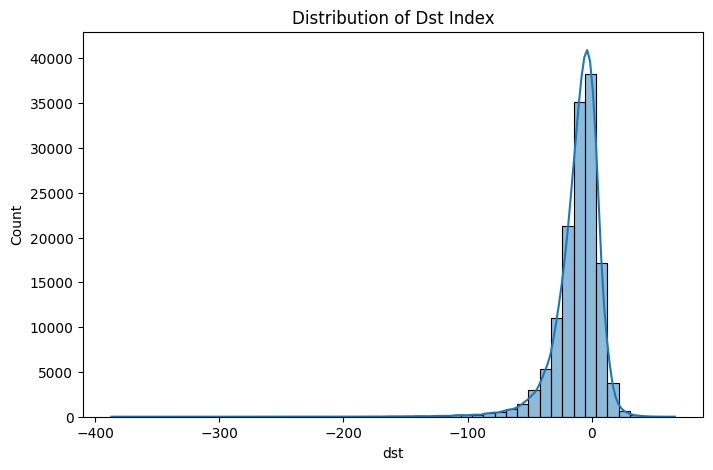

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(dst_labels["dst"], bins=50, kde=True)
plt.title("Distribution of Dst Index")
plt.show()

- The distribution is heavily concentrated around 0 nT, indicating that most observations correspond to quiet geomagnetic conditions.

- The distribution is negatively skewed, with a long tail extending toward large negative values. This reflects the occurrence of geomagnetic storms, which cause significant decreases in the Dst index.

- Extreme storm events (Dst < -100 nT) are relatively rare compared to normal conditions, resulting in an imbalanced target distribution.

- The presence of outliers reaching below -350 nT indicates that the dataset includes severe geomagnetic storms, which are important for model learning but may be difficult to predict accurately.

- Since most samples are clustered near zero, evaluation metrics should be monitored carefully to ensure that the model does not perform well only on quiet periods while failing to capture extreme storm events.

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

for period in dst_labels.index.get_level_values("period").unique():
    subset = dst_labels.loc[period]

    fig.add_trace(
        go.Scatter(
            x=subset.index.total_seconds() / 3600,
            y=subset["dst"],
            mode="lines",
            name=period
        )
    )

fig.update_layout(
    title="Dst Time Series by Period",
    xaxis_title="Hours",
    yaxis_title="Dst",
    height=600
)

fig.show()

- The `Dst` index is highly imbalanced, with most observations concentrated near zero and only a few extreme negative values corresponding to intense geomagnetic storms. This should be considered during model training and evaluation.

- Storm intensity varies significantly across `train_a`, `train_b`, and `train_c`, indicating that the dataset captures a wide range of geomagnetic conditions, which can improve the model's ability to generalize.

- Geomagnetic storms appear as sudden drops in the `Dst` index rather than gradual changes, suggesting that temporal features such as lagged values and rolling statistics may improve predictive performance.

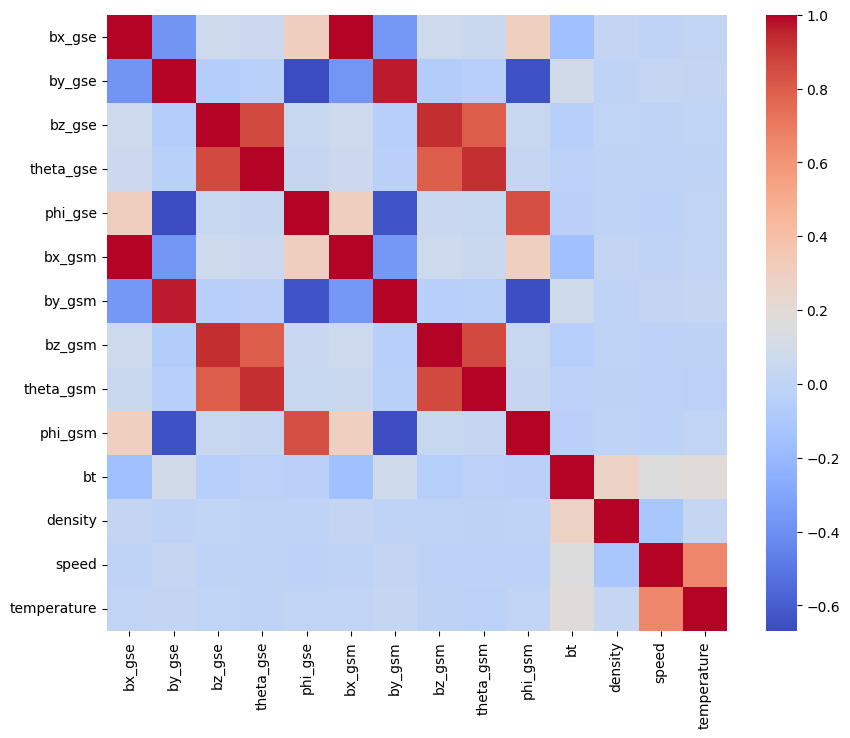

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(solar_wind.corr(numeric_only=True), cmap="coolwarm")
plt.show()

- The strong similarity between corresponding GSE and GSM variables indicates substantial feature redundancy, suggesting that dimensionality reduction or selective feature retention may simplify the model without significant information loss.

- Magnetic field components exhibit stronger inter-feature relationships than plasma parameters, highlighting their dominant role in characterizing solar-wind conditions.

In [ ]:
cols =['bx_gse', 'bx_gsm','by_gse',  'by_gsm','bz_gse', 'bz_gsm', 'theta_gse', 'theta_gsm', 'phi_gse',
       'phi_gsm', 'bt', 'density', 'speed',
       'temperature']


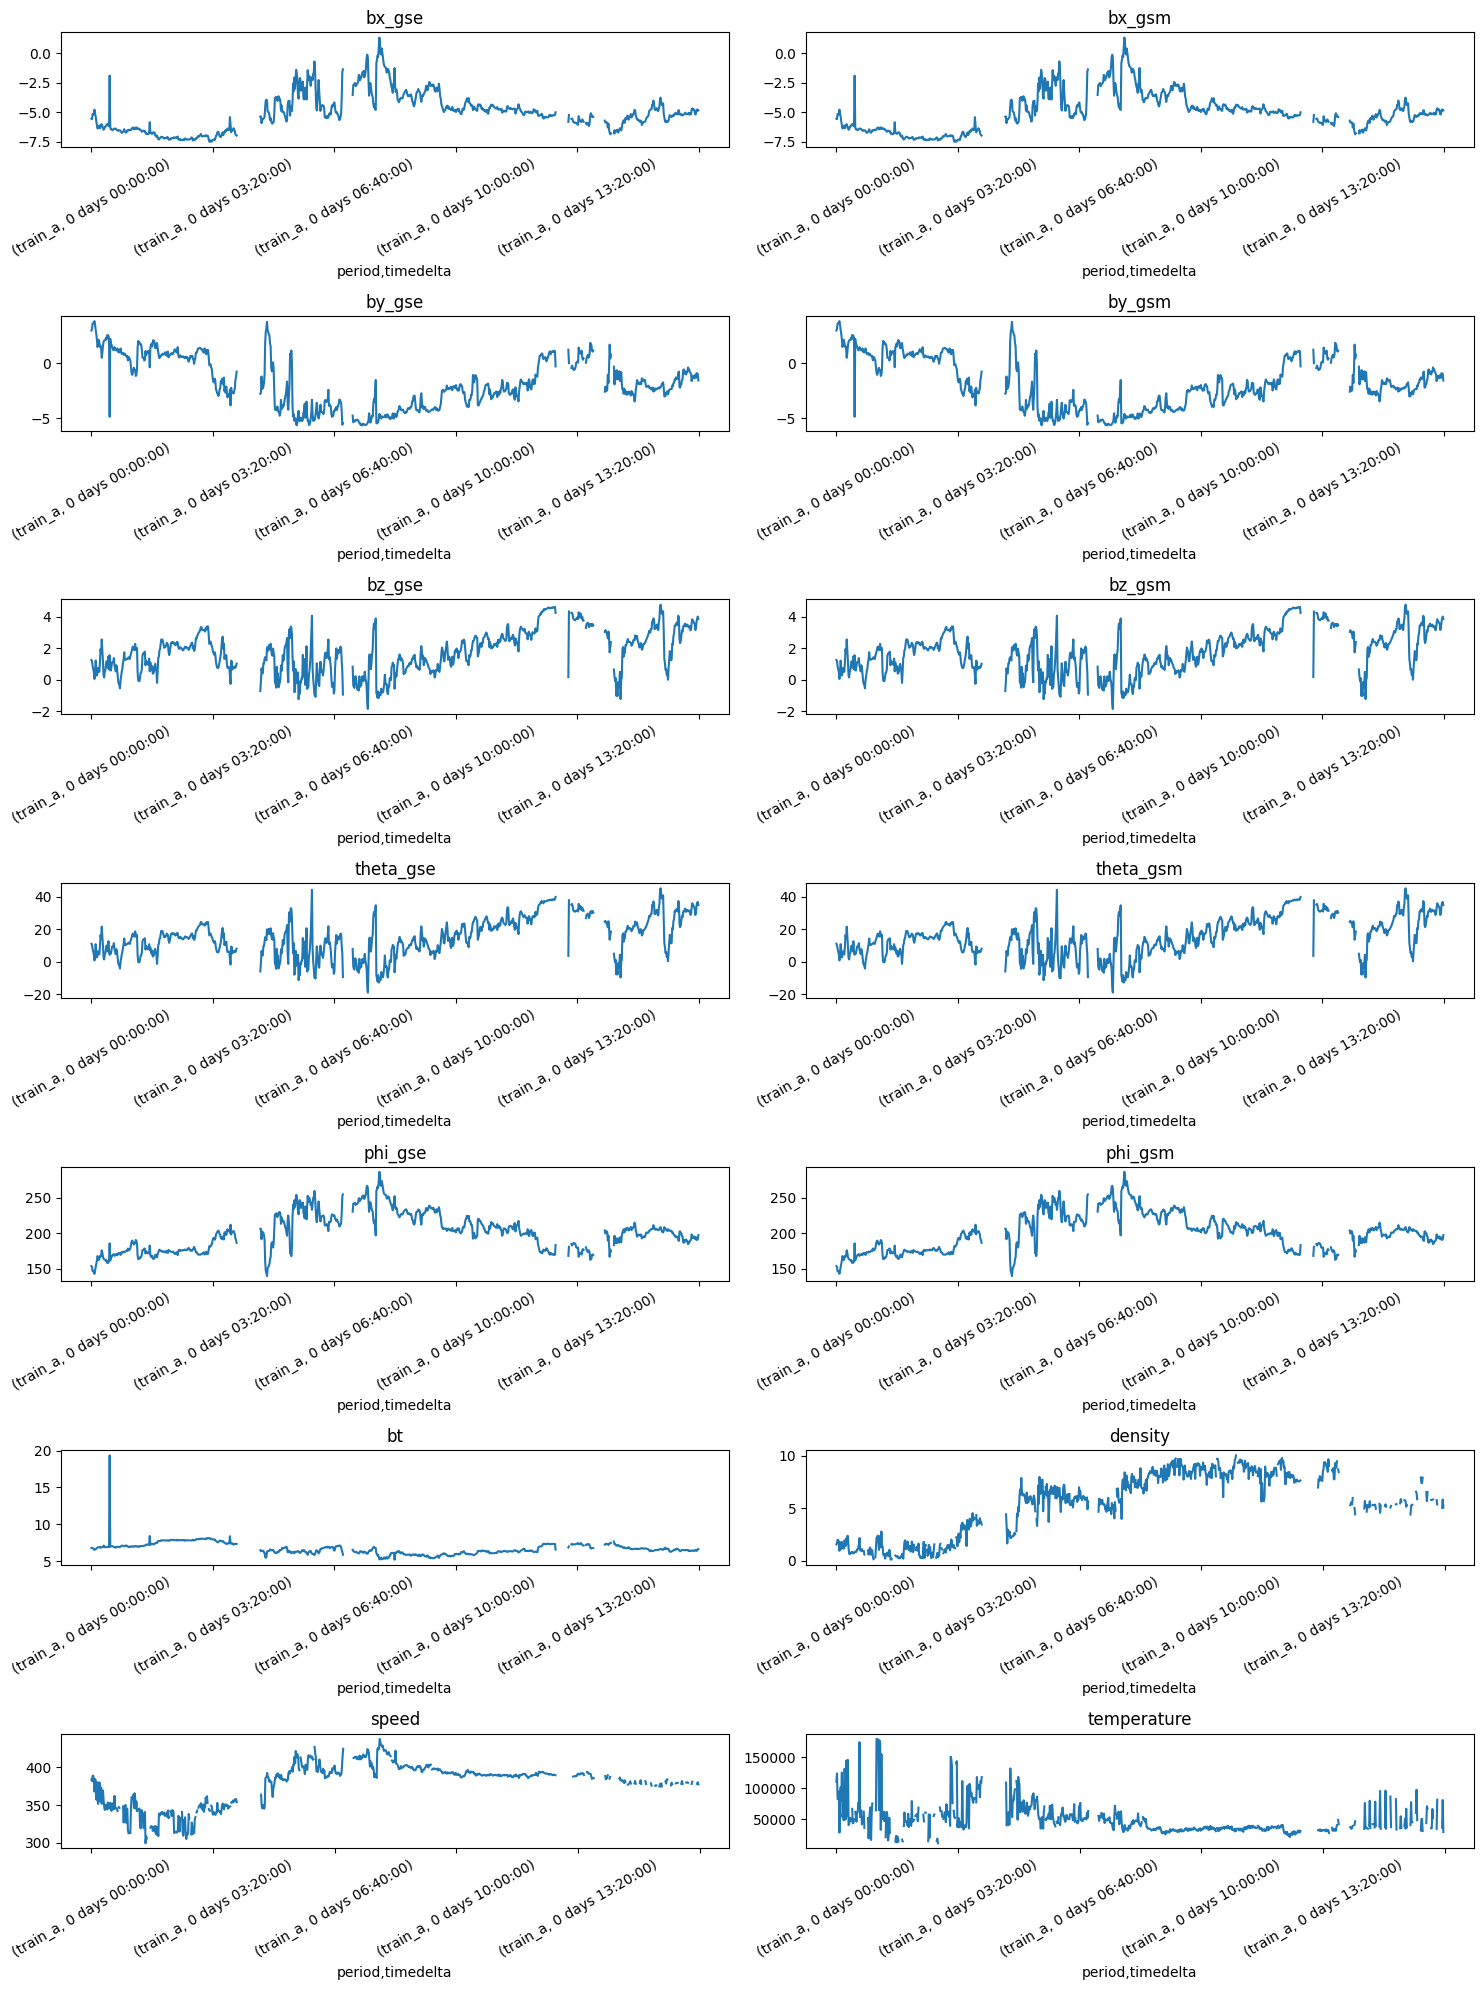

In [ ]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(15, 20))
for i, key in enumerate(cols):
  solar_wind.iloc[:1000][key].plot(ax=axes[i//2, i%2], title=key, rot= 30)
plt.tight_layout()
plt.show()

- Corresponding GSE and GSM magnetic field features (`bx`, `by`, `bz`, `theta`, and `phi`) exhibit nearly identical temporal patterns, confirming the strong correlation observed in the correlation analysis.

- Plasma parameters (`density`, `speed`, and `temperature`) show noticeable temporal variations and abrupt changes, indicating their potential importance in capturing geomagnetic disturbances.

- Several features contain spikes and rapid fluctuations, suggesting that lag-based and rolling-window features may help the model capture short-term dynamics more effectively.

### Ask & Answer Questions

The following questions will be explored during data analysis with respect to the training data:

1. What are the Dst values when there are no significant or abrupt changes in solar wind features such as `speed`, `temperature`, and `density`?

2. How are the solar wind features related to the Dst index?

3. Based on these relationships, what Dst values are observed at the minimum and maximum ranges of important features?

4. Through reverse analysis, which solar wind feature conditions correspond to the highest and lowest Dst values?

5. What is the mode Dst value, and during which time periods does it occur?

**Analysis range:**

The analysis is performed on the time-series data from:

`('train_a', Timedelta('0 days 00:00:00'))`
to
`('train_a', Timedelta('0 days 13:00:00'))`

in accordance with the above graph.


### 1. What are the Dst values when there are no significant or abrupt changes in solar wind features such as `speed`, `temperature`, and `density`?

In [ ]:
for period, t in [
    ('train_a', pd.Timedelta('0 days 02:00:00')),
    ('train_a', pd.Timedelta('0 days 10:00:00'))
]:
    sw = solar_wind.loc[(period, t)]
    print(
        f"\nAt {period}, {t}:"
        f"\n  dst: {dst_labels.loc[(period, t), 'dst']}"
        f"\n  speed: {sw['speed']:.2f}"
        f"\n  temperature: {sw['temperature']:.2f}"
        f"\n  density: {sw['density']:.2f}"
        f"\n  bt: {sw['bt']:.2f}"
    )


At train_a, 0 days 02:00:00:
  dst: -10
  speed: 336.55
  temperature: 44423.00
  density: 1.27
  bt: 7.84

At train_a, 0 days 10:00:00:
  dst: 1
  speed: 391.62
  temperature: 33404.00
  density: 8.84
  bt: 5.97


###  2. How are the solar wind features related to the Dst index?

Observations

* A Dst value of **-10** at the 2nd hour indicates a small geomagnetic disturbance compared with the Dst value of **1** at the 10th hour, which represents a relatively stable condition as observed in the graph.

* The solar wind speed appears to be lower during the period associated with the disturbance conditions.

* The temperature shows an increase during the period when the disturbance is observed.

* The density is relatively lower during the same period, which is observed alongside the increase in temperature.

* The magnetic field strength (`bt`) shows higher values during the disturbance period, indicating stronger magnetic field activity.

These observations can also be clearly seen from the above graph.

Since the conditions around the 2nd hour appear to be more disturbed, higher fluctuations are observed in the `speed` and `temperature` features near this region.


### 3. Based on these relationships, what Dst values are observed at the minimum and maximum ranges of important features?

In [ ]:
import pandas as pd

def analyze_feature(feature):
    sw = solar_wind.loc[
        ('train_a', pd.Timedelta('0 days 00:00:00')):
        ('train_a', pd.Timedelta('0 days 13:00:00'))
    ]

    max_idx = sw[feature].idxmax()
    min_idx = sw[feature].idxmin()

    max_dst = dst_labels.loc[(max_idx[0], max_idx[1].round('h')), 'dst']
    min_dst = dst_labels.loc[(min_idx[0], min_idx[1].round('h')), 'dst']

    print(f"\n{feature}")
    print(f"Max ({sw.loc[max_idx, feature]:.2f}) → Dst = {max_dst}")
    print(f"Min ({sw.loc[min_idx, feature]:.2f}) → Dst = {min_dst}")

for feature in ['speed', 'temperature', 'density', 'bt']:
    analyze_feature(feature)


speed
Max (437.79) → Dst = 3
Min (299.38) → Dst = -10

temperature
Max (179422.00) → Dst = -10
Min (11052.00) → Dst = -6

density
Max (10.03) → Dst = 2
Min (0.08) → Dst = -10

bt
Max (19.34) → Dst = -7
Min (5.22) → Dst = 3


These findings are consistent with the above observations.

### 4. Through reverse analysis, which solar wind feature conditions correspond to the highest and lowest Dst values?

In [ ]:
dst_range = dst_labels.loc[
    ('train_a', pd.Timedelta('0 days 00:00:00')):
    ('train_a', pd.Timedelta('0 days 13:00:00'))
]

for name, idx in [('Min DST', dst_range['dst'].idxmin()),
                  ('Max DST', dst_range['dst'].idxmax())]:
    print(f"\n{name}: {dst_range.loc[idx, 'dst']} at {idx}")
    print(solar_wind.loc[idx][['speed', 'temperature', 'density', 'bt']])


Min DST: -10 at ('train_a', Timedelta('0 days 01:00:00'))
speed          317.16
temperature       NaN
density          0.36
bt               7.01
Name: (train_a, 0 days 01:00:00), dtype: float64

Max DST: 5 at ('train_a', Timedelta('0 days 06:00:00'))
speed            415.51
temperature    38303.00
density            5.98
bt                 6.40
Name: (train_a, 0 days 06:00:00), dtype: float64


These findings are also consistent with the observed relationship.

### 5. What is the mode Dst value, and during which time periods does it occur?

In [ ]:
dst_range = dst_labels.loc[
    ('train_a', pd.Timedelta('0 days 00:00:00')):
    ('train_a', pd.Timedelta('0 days 13:00:00'))
]

for m in dst_range['dst'].mode():
    print(f"\nDST = {m}")
    print(dst_range[dst_range['dst'] == m].index.get_level_values('timedelta').tolist())


DST = 3
[Timedelta('0 days 05:00:00'), Timedelta('0 days 08:00:00'), Timedelta('0 days 13:00:00')]


This analysis did not provide significant insights.

## 3. Feature Engineering & Merging

1. Initialize the feature table from Dst labels.
2. Generate rolling statistics from minute-level solar wind data.
3. Align solar wind features with hourly Dst timestamps.
4. Create lag-based solar wind features.
5. Generate GSM Magnetic Field Features
6. Merge Satellite Position Features
7. Merge Sunspot Features

### Step 1: Initialize the feature table from Dst labels.

In [ ]:
# Base table: one row = one Dst prediction target
features = dst_labels.reset_index()

print(features.shape)
features.head()

(139872, 3)


,period,timedelta,dst
0,train_a,0 days 00:00:00,-7
1,train_a,0 days 01:00:00,-10
2,train_a,0 days 02:00:00,-10
3,train_a,0 days 03:00:00,-6
4,train_a,0 days 04:00:00,-2


In [ ]:
# Base table: one row = one Dst prediction target
features_test = dst_labels_test.reset_index()

print(features_test.shape)
features_test.head()

(59184, 3)


,period,timedelta,dst
0,test_a,0 days 00:00:00,16
1,test_a,0 days 01:00:00,15
2,test_a,0 days 02:00:00,15
3,test_a,0 days 03:00:00,14
4,test_a,0 days 04:00:00,14


### Step 2: Generate rolling statistics from minute-level solar wind data.

In [ ]:
# Rolling mean features: 1h, 3h, 6h, 12h, 24h

cols = ['speed', 'density', 'temperature', 'bt']

windows = {
    '1h': 60,
    '3h': 180,
    '6h': 360,
    '12h': 720,
    '24h': 1440
}

for col in cols:
    for name, window in windows.items():
        solar_wind[f'{col}_mean_{name}'] = (
            solar_wind.groupby(level='period')[col]
            .rolling(window, min_periods=1)
            .mean()
            .droplevel(0)
        )
        solar_wind_test[f'{col}_mean_{name}'] = (
            solar_wind_test.groupby(level='period')[col]
            .rolling(window, min_periods=1)
            .mean()
            .droplevel(0)
        )

print("Rolling features created.")

Rolling features created.


In [ ]:
solar_wind.filter(like='speed_mean').head()

speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period  timedelta                                                      
train_a 0 days 00:00:00       383.9200       383.9200       383.9200   
        0 days 00:01:00       382.8550       382.8550       382.8550   
        0 days 00:02:00       384.9400       384.9400       384.9400   
        0 days 00:03:00       385.9825       385.9825       385.9825   
        0 days 00:04:00       385.6380       385.6380       385.6380   

                         speed_mean_12h  speed_mean_24h  
period  timedelta                                        
train_a 0 days 00:00:00        383.9200        383.9200  
        0 days 00:01:00        382.8550        382.8550  
        0 days 00:02:00        384.9400        384.9400  
        0 days 00:03:00        385.9825        385.9825  
        0 days 00:04:00        385.6380        385.6380

In [ ]:
solar_wind_test.filter(like='speed_mean').head()

speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period timedelta                                                      
test_a 0 days 00:00:00     338.590000     338.590000     338.590000   
       0 days 00:01:00     338.850000     338.850000     338.850000   
       0 days 00:02:00     338.466667     338.466667     338.466667   
       0 days 00:03:00     338.452500     338.452500     338.452500   
       0 days 00:04:00     338.088000     338.088000     338.088000   

                        speed_mean_12h  speed_mean_24h  
period timedelta                                        
test_a 0 days 00:00:00      338.590000      338.590000  
       0 days 00:01:00      338.850000      338.850000  
       0 days 00:02:00      338.466667      338.466667  
       0 days 00:03:00      338.452500      338.452500  
       0 days 00:04:00      338.088000      338.088000

### Step 3: Align Solar Wind Features with Hourly Dst Timestamps

In [ ]:
rolling_cols = [c for c in solar_wind.columns if '_mean_' in c]
rolling_cols_test = [c for c in solar_wind_test.columns if '_mean_' in c]

sw_hourly = solar_wind[rolling_cols].loc[dst_labels.index]
sw_hourly_test = solar_wind_test[rolling_cols_test].loc[dst_labels_test.index]

features = dst_labels.join(sw_hourly)
features_test = dst_labels_test.join(sw_hourly_test)


In [ ]:
print(features.shape)
features.head()

(139872, 21)


dst  speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period  timedelta                                                           
train_a 0 days 00:00:00   -7     383.920000     383.920000     383.920000   
        0 days 01:00:00  -10     355.307692     355.847547     355.847547   
        0 days 02:00:00  -10     332.153091     343.780926     343.780926   
        0 days 03:00:00   -6     329.449038     338.841321     339.123063   
        0 days 04:00:00   -2     347.730179     336.642086     341.354537   

                         speed_mean_12h  speed_mean_24h  density_mean_1h  \
period  timedelta                                                          
train_a 0 days 00:00:00      383.920000      383.920000         1.530000   
        0 days 01:00:00      355.847547      355.847547         1.200192   
        0 days 02:00:00      343.780926      343.780926         0.885273   
        0 days 03:00:00      339.123063      339.123063         0.922885   
        0 days 04:00:00      341.354537      341.354537         2.789643   

                         density_mean_3h  density_mean_6h  density_mean_12h  \
period  timedelta                                                             
train_a 0 days 00:00:00         1.530000         1.530000          1.530000   
        0 days 01:00:00         1.206415         1.206415          1.206415   
        0 days 02:00:00         1.042870         1.042870          1.042870   
        0 days 03:00:00         1.000566         1.003875          1.003875   
        0 days 04:00:00         1.551534         1.466852          1.466852   

                         ...  temperature_mean_1h  temperature_mean_3h  \
period  timedelta        ...                                             
train_a 0 days 00:00:00  ...        110237.000000        110237.000000   
        0 days 01:00:00  ...         70303.450980         71071.403846   
        0 days 02:00:00  ...         58994.340909         65536.083333   
        0 days 03:00:00  ...         48600.500000         60361.248120   
        0 days 04:00:00  ...         77334.035714         63574.463768   

                         temperature_mean_6h  temperature_mean_12h  \
period  timedelta                                                    
train_a 0 days 00:00:00        110237.000000         110237.000000   
        0 days 01:00:00         71071.403846          71071.403846   
        0 days 02:00:00         65536.083333          65536.083333   
        0 days 03:00:00         60733.455224          60733.455224   
        0 days 04:00:00         65626.257895          65626.257895   

                         temperature_mean_24h  bt_mean_1h  bt_mean_3h  \
period  timedelta                                                       
train_a 0 days 00:00:00         110237.000000    6.800000    6.800000   
        0 days 01:00:00          71071.403846    7.143500    7.137869   
        0 days 02:00:00          65536.083333    7.298667    7.217603   
        0 days 03:00:00          60733.455224    7.875833    7.439333   
        0 days 04:00:00          65626.257895    7.743729    7.638827   

                         bt_mean_6h  bt_mean_12h  bt_mean_24h  
period  timedelta                                              
train_a 0 days 00:00:00    6.800000     6.800000     6.800000  
        0 days 01:00:00    7.137869     7.137869     7.137869  
        0 days 02:00:00    7.217603     7.217603     7.217603  
        0 days 03:00:00    7.435801     7.435801     7.435801  
        0 days 04:00:00    7.511500     7.511500     7.511500  

[5 rows x 21 columns]

In [ ]:
print(features_test.shape)
features_test.head()

(59184, 21)


dst  speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period timedelta                                                           
test_a 0 days 00:00:00   16     338.590000     338.590000     338.590000   
       0 days 01:00:00   15     338.264737     338.270345     338.270345   
       0 days 02:00:00   15     334.888621     336.579483     336.579483   
       0 days 03:00:00   14     333.778814     335.618276     335.635257   
       0 days 04:00:00   14     329.772931     332.818971     334.175966   

                        speed_mean_12h  speed_mean_24h  density_mean_1h  \
period timedelta                                                          
test_a 0 days 00:00:00      338.590000      338.590000         5.570000   
       0 days 01:00:00      338.270345      338.270345         5.382632   
       0 days 02:00:00      336.579483      336.579483         5.426207   
       0 days 03:00:00      335.635257      335.635257         5.477797   
       0 days 04:00:00      334.175966      334.175966         4.815517   

                        density_mean_3h  density_mean_6h  density_mean_12h  \
period timedelta                                                             
test_a 0 days 00:00:00         5.570000         5.570000          5.570000   
       0 days 01:00:00         5.385862         5.385862          5.385862   
       0 days 02:00:00         5.406034         5.406034          5.406034   
       0 days 03:00:00         5.429425         5.430229          5.430229   
       0 days 04:00:00         5.241200         5.277210          5.277210   

                        ...  temperature_mean_1h  temperature_mean_3h  \
period timedelta        ...                                             
test_a 0 days 00:00:00  ...         41313.000000         41313.000000   
       0 days 01:00:00  ...         40995.105263         41000.586207   
       0 days 02:00:00  ...         44558.982759         42779.784483   
       0 days 03:00:00  ...         45533.728814         43722.022989   
       0 days 04:00:00  ...         45391.689655         45163.594286   

                        temperature_mean_6h  temperature_mean_12h  \
period timedelta                                                    
test_a 0 days 00:00:00         41313.000000          41313.000000   
       0 days 01:00:00         41000.586207          41000.586207   
       0 days 02:00:00         42779.784483          42779.784483   
       0 days 03:00:00         43708.257143          43708.257143   
       0 days 04:00:00         44127.309013          44127.309013   

                        temperature_mean_24h  bt_mean_1h  bt_mean_3h  \
period timedelta                                                       
test_a 0 days 00:00:00          41313.000000    4.910000    4.910000   
       0 days 01:00:00          41000.586207    5.015167    5.013443   
       0 days 02:00:00          42779.784483    5.197833    5.104876   
       0 days 03:00:00          43708.257143    5.683833    5.298944   
       0 days 04:00:00          44127.309013    6.072000    5.651222   

                        bt_mean_6h  bt_mean_12h  bt_mean_24h  
period timedelta                                              
test_a 0 days 00:00:00    4.910000     4.910000     4.910000  
       0 days 01:00:00    5.013443     5.013443     5.013443  
       0 days 02:00:00    5.104876     5.104876     5.104876  
       0 days 03:00:00    5.296796     5.296796     5.296796  
       0 days 04:00:00    5.489793     5.489793     5.489793  

[5 rows x 21 columns]

### Step 4: Create Lag Features from Solar Wind Data

In [ ]:
lag_hours = [1, 3, 6, 12, 24]
cols = ['speed', 'density', 'temperature', 'bt']

for col in cols:
    for lag in lag_hours:
        features[f'{col}_lag_{lag}h'] = (
            solar_wind[col]
            .loc[dst_labels.index]
            .groupby(level='period')
            .shift(lag)
        )
        features_test[f'{col}_lag_{lag}h'] = (
                    solar_wind_test[col]
                    .loc[dst_labels_test.index]
                    .groupby(level='period')
                    .shift(lag)
                )

print("Lag features created.")

Lag features created.


In [ ]:
features.filter(like='speed_lag').head()

speed_lag_1h  speed_lag_3h  speed_lag_6h  \
period  timedelta                                                   
train_a 0 days 00:00:00           NaN           NaN           NaN   
        0 days 01:00:00        383.92           NaN           NaN   
        0 days 02:00:00        317.16           NaN           NaN   
        0 days 03:00:00        336.55        383.92           NaN   
        0 days 04:00:00        352.57        317.16           NaN   

                         speed_lag_12h  speed_lag_24h  
period  timedelta                                      
train_a 0 days 00:00:00            NaN            NaN  
        0 days 01:00:00            NaN            NaN  
        0 days 02:00:00            NaN            NaN  
        0 days 03:00:00            NaN            NaN  
        0 days 04:00:00            NaN            NaN

In [ ]:
features.shape, features_test.shape

((139872, 41), (59184, 41))

### Step 5: Generate GSM Magnetic Field Features

In [ ]:
mag_cols = ['bx_gsm', 'by_gsm', 'bz_gsm']

windows = {
    '1h': 60,
    '3h': 180,
    '6h': 360,
    '12h': 720,
    '24h': 1440
}

for col in mag_cols:
    for name, window in windows.items():
        solar_wind[f'{col}_mean_{name}'] = (
            solar_wind.groupby(level='period')[col]
            .rolling(window, min_periods=1)
            .mean()
            .droplevel(0)
        )
        solar_wind_test[f'{col}_mean_{name}'] = (
            solar_wind_test.groupby(level='period')[col]
            .rolling(window, min_periods=1)
            .mean()
            .droplevel(0)
        )

In [ ]:
gsm_features = solar_wind[
    [c for c in solar_wind.columns
     if c.startswith(('bx_gsm_mean_', 'by_gsm_mean_', 'bz_gsm_mean_'))]
].loc[dst_labels.index]

features = features.join(gsm_features)

In [ ]:
features.filter(like='bz_gsm').head()

bz_gsm_mean_1h  bz_gsm_mean_3h  bz_gsm_mean_6h  \
period  timedelta                                                         
train_a 0 days 00:00:00        1.250000        1.250000        1.250000   
        0 days 01:00:00        0.846333        0.852951        0.852951   
        0 days 02:00:00        1.276333        1.062893        1.062893   
        0 days 03:00:00        2.221833        1.448167        1.447072   
        0 days 04:00:00        1.744068        1.747430        1.520083   

                         bz_gsm_mean_12h  bz_gsm_mean_24h  
period  timedelta                                          
train_a 0 days 00:00:00         1.250000         1.250000  
        0 days 01:00:00         0.852951         0.852951  
        0 days 02:00:00         1.062893         1.062893  
        0 days 03:00:00         1.447072         1.447072  
        0 days 04:00:00         1.520083         1.520083

In [ ]:
gsm_features_test = solar_wind_test[
    [c for c in solar_wind_test.columns
     if c.startswith(('bx_gsm_mean_', 'by_gsm_mean_', 'bz_gsm_mean_'))]
].loc[dst_labels_test.index]

features_test = features_test.join(gsm_features_test)

In [ ]:
features.filter(like='bz_gsm').head()

bz_gsm_mean_1h  bz_gsm_mean_3h  bz_gsm_mean_6h  \
period  timedelta                                                         
train_a 0 days 00:00:00        1.250000        1.250000        1.250000   
        0 days 01:00:00        0.846333        0.852951        0.852951   
        0 days 02:00:00        1.276333        1.062893        1.062893   
        0 days 03:00:00        2.221833        1.448167        1.447072   
        0 days 04:00:00        1.744068        1.747430        1.520083   

                         bz_gsm_mean_12h  bz_gsm_mean_24h  
period  timedelta                                          
train_a 0 days 00:00:00         1.250000         1.250000  
        0 days 01:00:00         0.852951         0.852951  
        0 days 02:00:00         1.062893         1.062893  
        0 days 03:00:00         1.447072         1.447072  
        0 days 04:00:00         1.520083         1.520083

In [ ]:
features.shape, features_test.shape

((139872, 56), (59184, 56))

### Step 6: Merge Satellite Position Features

In [ ]:
def expand_satellite_positions(satellite_positions, dst_labels):
  expanded_sat = []

  for period in dst_labels.index.get_level_values('period').unique():

      dst_idx = dst_labels.loc[period].index

      sat = satellite_positions.loc[period]

      sat = sat.reindex(dst_idx, method='ffill')

      sat['period'] = period
      sat = sat.set_index('period', append=True)
      sat = sat.reorder_levels(['period', 'timedelta'])

      expanded_sat.append(sat)
  return expanded_sat

expanded_sat = expand_satellite_positions(satellite_positions, dst_labels)

satellite_hourly = pd.concat(expanded_sat).sort_index()

In [ ]:
features = features.join(satellite_hourly)

In [ ]:
expanded_sat = expand_satellite_positions(satellite_positions_test, dst_labels_test)

satellite_hourly_test = pd.concat(expanded_sat).sort_index()
features_test = features_test.join(satellite_hourly_test)

In [ ]:
features.shape, features_test.shape

((139872, 62), (59184, 62))

### Step 7: Merge Sunspot Features

In [ ]:
def Merge_sunspots(sunspots, dst_labels):
  expanded_ss = []

  for period in dst_labels.index.get_level_values('period').unique():

      dst_idx = dst_labels.loc[period].index

      ss = sunspots.loc[period]

      ss = ss.reindex(dst_idx, method='ffill')

      ss['period'] = period
      ss = ss.set_index('period', append=True)
      ss = ss.reorder_levels(['period', 'timedelta'])

      expanded_ss.append(ss)
  return expanded_ss

expanded_ss = Merge_sunspots(sunspots, dst_labels)

sunspots_hourly = pd.concat(expanded_ss).sort_index()

In [ ]:
features = features.join(sunspots_hourly)

print(features.shape)

(139872, 63)


In [ ]:
expanded_ss = Merge_sunspots(sunspots_test, dst_labels_test)

sunspots_hourly_test = pd.concat(expanded_ss).sort_index()
features_test = features_test.join(sunspots_hourly_test)
features_test.shape

(59184, 63)


Delete unwanted data to save **RAM**.

In [ ]:
del solar_wind, satellite_positions, sunspots, dst_labels

In [ ]:
del solar_wind_test, satellite_positions_test, sunspots_test, dst_labels_test

## 4. Create required Target Features to complete the features set
In this step, the target features are completed by creating a new column, `dst_future`, which represents the **Dst value one hour into the future**. This is generated by shifting the current `dst` values within each `period`, allowing the model to learn and predict future geomagnetic conditions based on current observations.

The same feature structure is maintained for both training and test datasets to ensure consistency during model training and evaluation.

- Complete Train Features
- Complete test Features

### Complete Train Features

In [ ]:
features['dst_future'] = features.groupby('period')['dst'].shift(-1)

In [ ]:
features.head()

dst  speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period  timedelta                                                           
train_a 0 days 00:00:00   -7     383.920000     383.920000     383.920000   
        0 days 01:00:00  -10     355.307692     355.847547     355.847547   
        0 days 02:00:00  -10     332.153091     343.780926     343.780926   
        0 days 03:00:00   -6     329.449038     338.841321     339.123063   
        0 days 04:00:00   -2     347.730179     336.642086     341.354537   

                         speed_mean_12h  speed_mean_24h  density_mean_1h  \
period  timedelta                                                          
train_a 0 days 00:00:00      383.920000      383.920000         1.530000   
        0 days 01:00:00      355.847547      355.847547         1.200192   
        0 days 02:00:00      343.780926      343.780926         0.885273   
        0 days 03:00:00      339.123063      339.123063         0.922885   
        0 days 04:00:00      341.354537      341.354537         2.789643   

                         density_mean_3h  density_mean_6h  density_mean_12h  \
period  timedelta                                                             
train_a 0 days 00:00:00         1.530000         1.530000          1.530000   
        0 days 01:00:00         1.206415         1.206415          1.206415   
        0 days 02:00:00         1.042870         1.042870          1.042870   
        0 days 03:00:00         1.000566         1.003875          1.003875   
        0 days 04:00:00         1.551534         1.466852          1.466852   

                         ...  bz_gsm_mean_12h  bz_gsm_mean_24h  gse_x_ace  \
period  timedelta        ...                                                
train_a 0 days 00:00:00  ...         1.250000         1.250000  1522376.9   
        0 days 01:00:00  ...         0.852951         0.852951  1522376.9   
        0 days 02:00:00  ...         1.062893         1.062893  1522376.9   
        0 days 03:00:00  ...         1.447072         1.447072  1522376.9   
        0 days 04:00:00  ...         1.520083         1.520083  1522376.9   

                         gse_y_ace  gse_z_ace  gse_x_dscovr  gse_y_dscovr  \
period  timedelta                                                           
train_a 0 days 00:00:00   143704.6   149496.7           NaN           NaN   
        0 days 01:00:00   143704.6   149496.7           NaN           NaN   
        0 days 02:00:00   143704.6   149496.7           NaN           NaN   
        0 days 03:00:00   143704.6   149496.7           NaN           NaN   
        0 days 04:00:00   143704.6   149496.7           NaN           NaN   

                         gse_z_dscovr  smoothed_ssn  dst_future  
period  timedelta                                                
train_a 0 days 00:00:00           NaN          65.4       -10.0  
        0 days 01:00:00           NaN          65.4       -10.0  
        0 days 02:00:00           NaN          65.4        -6.0  
        0 days 03:00:00           NaN          65.4        -2.0  
        0 days 04:00:00           NaN          65.4         3.0  

[5 rows x 64 columns]

### - Complete Test Features

In [ ]:
features_test['dst_future'] = features_test.groupby('period')['dst'].shift(-1)

In [ ]:
features_test.head()

dst  speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period timedelta                                                           
test_a 0 days 00:00:00   16     338.590000     338.590000     338.590000   
       0 days 01:00:00   15     338.264737     338.270345     338.270345   
       0 days 02:00:00   15     334.888621     336.579483     336.579483   
       0 days 03:00:00   14     333.778814     335.618276     335.635257   
       0 days 04:00:00   14     329.772931     332.818971     334.175966   

                        speed_mean_12h  speed_mean_24h  density_mean_1h  \
period timedelta                                                          
test_a 0 days 00:00:00      338.590000      338.590000         5.570000   
       0 days 01:00:00      338.270345      338.270345         5.382632   
       0 days 02:00:00      336.579483      336.579483         5.426207   
       0 days 03:00:00      335.635257      335.635257         5.477797   
       0 days 04:00:00      334.175966      334.175966         4.815517   

                        density_mean_3h  density_mean_6h  density_mean_12h  \
period timedelta                                                             
test_a 0 days 00:00:00         5.570000         5.570000          5.570000   
       0 days 01:00:00         5.385862         5.385862          5.385862   
       0 days 02:00:00         5.406034         5.406034          5.406034   
       0 days 03:00:00         5.429425         5.430229          5.430229   
       0 days 04:00:00         5.241200         5.277210          5.277210   

                        ...  bz_gsm_mean_12h  bz_gsm_mean_24h  gse_x_ace  \
period timedelta        ...                                                
test_a 0 days 00:00:00  ...         0.140000         0.140000  1500809.1   
       0 days 01:00:00  ...         0.513115         0.513115  1500809.1   
       0 days 02:00:00  ...        -0.614959        -0.614959  1500809.1   
       0 days 03:00:00  ...        -0.179779        -0.179779  1500809.1   
       0 days 04:00:00  ...         0.185768         0.185768  1500809.1   

                        gse_y_ace  gse_z_ace  gse_x_dscovr  gse_y_dscovr  \
period timedelta                                                           
test_a 0 days 00:00:00   260858.4   -60904.6           NaN           NaN   
       0 days 01:00:00   260858.4   -60904.6           NaN           NaN   
       0 days 02:00:00   260858.4   -60904.6           NaN           NaN   
       0 days 03:00:00   260858.4   -60904.6           NaN           NaN   
       0 days 04:00:00   260858.4   -60904.6           NaN           NaN   

                        gse_z_dscovr  smoothed_ssn  dst_future  
period timedelta                                                
test_a 0 days 00:00:00           NaN         167.4        15.0  
       0 days 01:00:00           NaN         167.4        15.0  
       0 days 02:00:00           NaN         167.4        14.0  
       0 days 03:00:00           NaN         167.4        14.0  
       0 days 04:00:00           NaN         167.4        14.0  

[5 rows x 64 columns]

In [ ]:
features.shape, features_test.shape

((139872, 64), (59184, 64))

## 5. Prepare Dataset for Training

- Fill/Remove Missing Values
- Split Training & Validation Set
- Extract Inputs & Outputs
   - Training
   - Validation
   - Test

### Fill/Remove Missing Values

In [ ]:
features.isna().sum().to_frame(name="count").T

,dst,speed_mean_1h,speed_mean_3h,speed_mean_6h,speed_mean_12h,speed_mean_24h,density_mean_1h,density_mean_3h,density_mean_6h,density_mean_12h,...,bz_gsm_mean_12h,bz_gsm_mean_24h,gse_x_ace,gse_y_ace,gse_z_ace,gse_x_dscovr,gse_y_dscovr,gse_z_dscovr,smoothed_ssn,dst_future
count,0,3242,1819,1211,842,534,3242,1819,1211,842,...,311,100,0,0,0,115056,115056,115056,0,3


As there are still NaN values present in many columns and dropping them would result in significant data loss, the ffill (forward fill) and bfill (backward fill) methods are used for handling missing values.

In [ ]:
features = features.groupby(level='period').ffill()

In [ ]:
features = features.groupby(level='period').bfill()

In [ ]:
features.isna().sum().sum()

np.int64(261864)

Some NaN values still remain after applying ffill and bfill. Therefore, the remaining missing values are filled using the median values of the respective features with fillna(features.median(numeric_only=True)).

In [ ]:
features = features.fillna(features.median(numeric_only=True))

In [ ]:
features.isna().sum().sum()

np.int64(0)

For Test Set

In [ ]:
features_test.isna().sum().to_frame(name="count").T

,dst,speed_mean_1h,speed_mean_3h,speed_mean_6h,speed_mean_12h,speed_mean_24h,density_mean_1h,density_mean_3h,density_mean_6h,density_mean_12h,...,bz_gsm_mean_12h,bz_gsm_mean_24h,gse_x_ace,gse_y_ace,gse_z_ace,gse_x_dscovr,gse_y_dscovr,gse_z_dscovr,smoothed_ssn,dst_future
count,0,695,379,234,156,83,695,379,234,156,...,119,45,0,0,0,47064,47064,47064,0,3


In [ ]:
features_test = features_test.groupby(level='period').ffill()
features_test = features_test.groupby(level='period').bfill()
features_test.fillna(features_test.median(numeric_only=True), inplace=True)

In [ ]:
features_test.isna().sum().sum()

np.int64(0)

### Split Training & Validation Set

We set aside **20% of the training data** as the validation set to evaluate model performance on previously unseen data.

Since this is time-series data, the split is performed **without shuffling** to preserve temporal order and avoid data leakage.

The data is split **separately for each `period` (`train_a`, `train_b`, `train_c`)**, where the first **80%** of each sequence is used for training and the remaining **20%** is reserved for validation.

After splitting each period independently, the subsets are concatenated to form the final `train_df` and `val_df`.


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_parts = []
val_parts = []

for period, df_period in features.groupby(level='period'):
    train_p, val_p = train_test_split(
        df_period,
        test_size=0.2,
        shuffle=False
    )

    train_parts.append(train_p)
    val_parts.append(val_p)

train_df = pd.concat(train_parts)
val_df = pd.concat(val_parts)

### Extract Inputs and Outputs
- Train Set
- Validate Set
- Test Set

#### Train Set

In [ ]:
X_train = train_df.drop(columns=["dst", "dst_future"])
y_train = train_df[["dst", "dst_future"]]


In [ ]:
X_train.head()

speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period  timedelta                                                      
train_a 0 days 00:00:00     383.920000     383.920000     383.920000   
        0 days 01:00:00     355.307692     355.847547     355.847547   
        0 days 02:00:00     332.153091     343.780926     343.780926   
        0 days 03:00:00     329.449038     338.841321     339.123063   
        0 days 04:00:00     347.730179     336.642086     341.354537   

                         speed_mean_12h  speed_mean_24h  density_mean_1h  \
period  timedelta                                                          
train_a 0 days 00:00:00      383.920000      383.920000         1.530000   
        0 days 01:00:00      355.847547      355.847547         1.200192   
        0 days 02:00:00      343.780926      343.780926         0.885273   
        0 days 03:00:00      339.123063      339.123063         0.922885   
        0 days 04:00:00      341.354537      341.354537         2.789643   

                         density_mean_3h  density_mean_6h  density_mean_12h  \
period  timedelta                                                             
train_a 0 days 00:00:00         1.530000         1.530000          1.530000   
        0 days 01:00:00         1.206415         1.206415          1.206415   
        0 days 02:00:00         1.042870         1.042870          1.042870   
        0 days 03:00:00         1.000566         1.003875          1.003875   
        0 days 04:00:00         1.551534         1.466852          1.466852   

                         density_mean_24h  ...  bz_gsm_mean_6h  \
period  timedelta                          ...                   
train_a 0 days 00:00:00          1.530000  ...        1.250000   
        0 days 01:00:00          1.206415  ...        0.852951   
        0 days 02:00:00          1.042870  ...        1.062893   
        0 days 03:00:00          1.003875  ...        1.447072   
        0 days 04:00:00          1.466852  ...        1.520083   

                         bz_gsm_mean_12h  bz_gsm_mean_24h  gse_x_ace  \
period  timedelta                                                      
train_a 0 days 00:00:00         1.250000         1.250000  1522376.9   
        0 days 01:00:00         0.852951         0.852951  1522376.9   
        0 days 02:00:00         1.062893         1.062893  1522376.9   
        0 days 03:00:00         1.447072         1.447072  1522376.9   
        0 days 04:00:00         1.520083         1.520083  1522376.9   

                         gse_y_ace  gse_z_ace  gse_x_dscovr  gse_y_dscovr  \
period  timedelta                                                           
train_a 0 days 00:00:00   143704.6   149496.7     1562145.0      180290.0   
        0 days 01:00:00   143704.6   149496.7     1562145.0      180290.0   
        0 days 02:00:00   143704.6   149496.7     1562145.0      180290.0   
        0 days 03:00:00   143704.6   149496.7     1562145.0      180290.0   
        0 days 04:00:00   143704.6   149496.7     1562145.0      180290.0   

                         gse_z_dscovr  smoothed_ssn  
period  timedelta                                    
train_a 0 days 00:00:00     -174170.0          65.4  
        0 days 01:00:00     -174170.0          65.4  
        0 days 02:00:00     -174170.0          65.4  
        0 days 03:00:00     -174170.0          65.4  
        0 days 04:00:00     -174170.0          65.4  

[5 rows x 62 columns]

In [ ]:
y_train

dst  dst_future
period  timedelta                          
train_a 0 days 00:00:00      -7       -10.0
        0 days 01:00:00     -10       -10.0
        0 days 02:00:00     -10        -6.0
        0 days 03:00:00      -6        -2.0
        0 days 04:00:00      -2         3.0
...                         ...         ...
train_c 1948 days 14:00:00   -3        -5.0
        1948 days 15:00:00   -5       -10.0
        1948 days 16:00:00  -10       -12.0
        1948 days 17:00:00  -12       -12.0
        1948 days 18:00:00  -12       -12.0

[111897 rows x 2 columns]

#### Validate Set

In [ ]:

X_val = val_df.drop(columns=["dst", "dst_future"])
y_val = val_df[["dst", "dst_future"]]

In [ ]:
X_val

speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period  timedelta                                                         
train_a 960 days 19:00:00      410.552712     422.482222     423.373977   
        960 days 20:00:00      399.448421     411.755116     420.119824   
        960 days 21:00:00      384.682759     398.291782     414.123275   
        960 days 22:00:00      394.031404     392.674128     407.534723   
        960 days 23:00:00      416.090526     398.189244     404.972180   
...                                   ...            ...            ...   
train_c 2435 days 19:00:00     344.919434     340.815855     347.743366   
        2435 days 20:00:00     337.438036     339.958735     343.128469   
        2435 days 21:00:00     334.383036     338.804303     339.727902   
        2435 days 22:00:00     348.531552     340.216529     340.499441   
        2435 days 23:00:00     343.270175     342.144327     341.067745   

                            speed_mean_12h  speed_mean_24h  density_mean_1h  \
period  timedelta                                                             
train_a 960 days 19:00:00       434.672142      428.919210         6.049831   
        960 days 20:00:00       429.309899      429.698136         6.422632   
        960 days 21:00:00       423.239071      429.760139         8.484138   
        960 days 22:00:00       418.391512      429.860480         8.150000   
        960 days 23:00:00       415.837162      430.926140        10.353684   
...                                    ...             ...              ...   
train_c 2435 days 19:00:00      352.433059      356.242071         2.770755   
        2435 days 20:00:00      350.617496      355.292406         2.818929   
        2435 days 21:00:00      349.086009      354.102123         2.323571   
        2435 days 22:00:00      348.709954      353.471075         2.311897   
        2435 days 23:00:00      347.150920      352.701920         2.119649   

                            density_mean_3h  density_mean_6h  \
period  timedelta                                              
train_a 960 days 19:00:00          5.232632         4.747281   
        960 days 20:00:00          6.030291         5.261559   
        960 days 21:00:00          6.983391         5.785526   
        960 days 22:00:00          7.690233         6.465015   
        960 days 23:00:00          8.992965         7.511628   
...                                     ...              ...   
train_c 2435 days 19:00:00         2.181645         2.930939   
        2435 days 20:00:00         2.538434         2.610326   
        2435 days 21:00:00         2.635333         2.338754   
        2435 days 22:00:00         2.482765         2.340621   
        2435 days 23:00:00         2.251637         2.392908   

                            density_mean_12h  density_mean_24h  ...  \
period  timedelta                                               ...   
train_a 960 days 19:00:00           5.100926          5.858815  ...   
        960 days 20:00:00           5.156870          5.968136  ...   
        960 days 21:00:00           5.381292          6.170681  ...   
        960 days 22:00:00           5.577020          6.366243  ...   
        960 days 23:00:00           5.980102          6.651543  ...   
...                                      ...               ...  ...   
train_c 2435 days 19:00:00          3.618402          4.877824  ...   
        2435 days 20:00:00          3.397618          4.708231  ...   
        2435 days 21:00:00          3.219052          4.498807  ...   
        2435 days 22:00:00          3.050199          4.318154  ...   
        2435 days 23:00:00          2.837607          4.147843  ...   

                            bz_gsm_mean_6h  bz_gsm_mean_12h  bz_gsm_mean_24h  \
period  timedelta                                                              
train_a 960 days 19:00:00         4.408750        -3.564667        -4.785004   
        960 days 20:00:00  

In [ ]:
y_val

dst  dst_future
period  timedelta                          
train_a 960 days 19:00:00   -45       -42.0
        960 days 20:00:00   -42       -36.0
        960 days 21:00:00   -36       -32.0
        960 days 22:00:00   -32       -26.0
        960 days 23:00:00   -26       -31.0
...                         ...         ...
train_c 2435 days 19:00:00  -16       -14.0
        2435 days 20:00:00  -14       -14.0
        2435 days 21:00:00  -14       -15.0
        2435 days 22:00:00  -15       -14.0
        2435 days 23:00:00  -14       -14.0

[27975 rows x 2 columns]

#### Test Set

In [ ]:

X_test = features_test.drop(columns=["dst", "dst_future"])
y_test = features_test[["dst", "dst_future"]]

In [ ]:
X_test.head()

speed_mean_1h  speed_mean_3h  speed_mean_6h  \
period timedelta                                                      
test_a 0 days 00:00:00     338.590000     338.590000     338.590000   
       0 days 01:00:00     338.264737     338.270345     338.270345   
       0 days 02:00:00     334.888621     336.579483     336.579483   
       0 days 03:00:00     333.778814     335.618276     335.635257   
       0 days 04:00:00     329.772931     332.818971     334.175966   

                        speed_mean_12h  speed_mean_24h  density_mean_1h  \
period timedelta                                                          
test_a 0 days 00:00:00      338.590000      338.590000         5.570000   
       0 days 01:00:00      338.270345      338.270345         5.382632   
       0 days 02:00:00      336.579483      336.579483         5.426207   
       0 days 03:00:00      335.635257      335.635257         5.477797   
       0 days 04:00:00      334.175966      334.175966         4.815517   

                        density_mean_3h  density_mean_6h  density_mean_12h  \
period timedelta                                                             
test_a 0 days 00:00:00         5.570000         5.570000          5.570000   
       0 days 01:00:00         5.385862         5.385862          5.385862   
       0 days 02:00:00         5.406034         5.406034          5.406034   
       0 days 03:00:00         5.429425         5.430229          5.430229   
       0 days 04:00:00         5.241200         5.277210          5.277210   

                        density_mean_24h  ...  bz_gsm_mean_6h  \
period timedelta                          ...                   
test_a 0 days 00:00:00          5.570000  ...        0.140000   
       0 days 01:00:00          5.385862  ...        0.513115   
       0 days 02:00:00          5.406034  ...       -0.614959   
       0 days 03:00:00          5.430229  ...       -0.179779   
       0 days 04:00:00          5.277210  ...        0.185768   

                        bz_gsm_mean_12h  bz_gsm_mean_24h  gse_x_ace  \
period timedelta                                                      
test_a 0 days 00:00:00         0.140000         0.140000  1500809.1   
       0 days 01:00:00         0.513115         0.513115  1500809.1   
       0 days 02:00:00        -0.614959        -0.614959  1500809.1   
       0 days 03:00:00        -0.179779        -0.179779  1500809.1   
       0 days 04:00:00         0.185768         0.185768  1500809.1   

                        gse_y_ace  gse_z_ace  gse_x_dscovr  gse_y_dscovr  \
period timedelta                                                           
test_a 0 days 00:00:00   260858.4   -60904.6     1478456.0      -16358.0   
       0 days 01:00:00   260858.4   -60904.6     1478456.0      -16358.0   
       0 days 02:00:00   260858.4   -60904.6     1478456.0      -16358.0   
       0 days 03:00:00   260858.4   -60904.6     1478456.0      -16358.0   
       0 days 04:00:00   260858.4   -60904.6     1478456.0      -16358.0   

                        gse_z_dscovr  smoothed_ssn  
period timedelta                                    
test_a 0 days 00:00:00      -22616.0         167.4  
       0 days 01:00:00      -22616.0         167.4  
       0 days 02:00:00      -22616.0         167.4  
       0 days 03:00:00      -22616.0         167.4  
       0 days 04:00:00      -22616.0         167.4  

[5 rows x 62 columns]

In [ ]:
y_test

dst  dst_future
period timedelta                         
test_a 0 days 00:00:00     16        15.0
       0 days 01:00:00     15        15.0
       0 days 02:00:00     15        14.0
       0 days 03:00:00     14        14.0
       0 days 04:00:00     14        14.0
...                       ...         ...
test_c 518 days 19:00:00  -10       -10.0
       518 days 20:00:00  -10       -10.0
       518 days 21:00:00  -10       -11.0
       518 days 22:00:00  -11       -14.0
       518 days 23:00:00  -14       -14.0

[59184 rows x 2 columns]

## 6. Train Hardcoded & Baseline Models

- Hardcoded model: always predict average
- Baseline model: Linear regression

### Hardcoded model: always predict average



In [ ]:
class MeanRegressor:
    def __init__(self):
        self.mean = None

    def fit(self, X, y):
        self.mean = y.mean()

    def predict(self, X):
        return np.tile(self.mean, (X.shape[0], 1))

In [ ]:
mean_regressor = MeanRegressor()
mean_regressor.fit(X_train, y_train)

In [ ]:
mean_regressor.mean

,0
dst,-11.613296
dst_future,-11.613823


In [ ]:
train_preds = mean_regressor.predict(X_train)
train_preds

array([[-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       ...,
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343]])

In [ ]:
val_preds = mean_regressor.predict(X_val)

In [ ]:
val_preds

array([[-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       ...,
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343],
       [-11.61329616, -11.61382343]])

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
rmse(y_train, train_preds)

np.float64(19.154007055720104)

In [ ]:
rmse(y_val, val_preds)

np.float64(18.768017551437403)

### Train & Evaluate Baseline Model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
train_preds = linear_model.predict(X_train)
train_preds

array([[ -1.66417023,  -1.45273534],
       [ -4.56362007,  -4.41272604],
       [ -3.81428427,  -3.1228667 ],
       ...,
       [-12.20301446, -12.00704032],
       [-13.97945085, -13.06824916],
       [-13.24161718, -12.39598509]])

In [ ]:
rmse(y_train, train_preds)

np.float64(12.036081553553693)

In [ ]:

rmse(y_val, linear_model.predict(X_val))

np.float64(11.7541426204191)

## 7. Make Predictions and Submit

Since the original NOAA MagNet competition is no longer accepting submissions, direct evaluation on the official leaderboard is not possible.

To approximate competition performance, a custom evaluation function was implemented using the **top 84 leaderboard RMSE scores** collected from the competition results.

The function generates predictions on the held-out test set, computes the model's **RMSE**, and compares it against the archived leaderboard scores to estimate:

* Estimated leaderboard rank
* Percentile position
* Gap from the top-ranked solution
* Relative performance compared to the best and worst submitted scores

This provides an approximate indication of how the model would have performed relative to the competition participants.


In [ ]:
def Submit_pred(Model):
  y_pred =Model.predict(X_test)
  score = rmse(y_test, y_pred)
  print(f'RMSE: {score}')

In [ ]:
Submit_pred(linear_model)

RMSE: 14.746012586294102


In [ ]:
# Top 84 scores from leaderboard
# At https://www.drivendata.org/competitions/73/noaa-magnetic-forecasting/leaderboard/?page=1
leaderboard_rmse = [
11.1311, 11.2532, 11.2944, 11.5293, 11.6183, 11.6504, 11.8901, 12.0454,
12.0934, 12.1709, 12.2093, 12.2132, 12.2638, 12.2818, 12.2936, 12.2944,
12.3331, 12.3930, 12.4926, 12.5052, 12.6541, 12.6884, 12.9517, 12.9644,
12.9943, 13.0829, 13.2140, 13.3773, 13.4623, 13.5665, 13.7338, 13.8521,
13.8534, 13.8691, 14.0397, 14.1238, 14.2263, 14.3769, 14.4797, 14.5263,
14.5359, 14.5733, 14.6351, 14.6709, 14.6709, 14.7291, 14.7481, 14.8335,
14.9129, 14.9288, 15.0111, 15.0485, 15.1234, 15.1627, 15.2102, 15.2404,
15.2516, 15.2825, 15.3451, 15.3516, 15.4819, 15.5855, 15.6037, 15.6663,
15.8995, 16.0298, 16.0845, 16.1478, 16.2600, 16.4062, 16.4163, 18.2221,
19.1626, 19.1886, 19.2325, 20.1389, 20.3431, 20.3867, 20.6279, 21.0663,
21.6405, 21.6405, 25.0934, 25.9543, 46.9243
]

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from IPython.display import display, HTML


def estimate_rank(model):

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(
        np.array(y_test).reshape(-1),
        np.array(y_pred).reshape(-1)
    ))

    lb = np.array(leaderboard_rmse)

    # rank (1 = best)
    rank = np.sum(lb < rmse) + 1

    percentile = 100 * (1 - rank / len(lb))

    best = lb.min()
    worst = lb.max()

    gap_to_best = rmse - best

    display(HTML(f"<h1><b>Rank : #{rank}</b></h1>"))
    print(f"Your RMSE: {rmse:.4f}")
    print(f"Rank : {rank} / {len(lb)}")
    print(f"Percentile: {percentile:.2f}%")
    print(f"Gap to #1: {gap_to_best:.4f}")
    print(f"Best: {best}, Worst: {worst}")

    return rmse, rank, percentile

In [ ]:
estimate_rank(linear_model)

Your RMSE: 14.7460
Rank : 47 / 85
Percentile: 44.71%
Gap to #1: 3.6149
Best: 11.1311, Worst: 46.9243


(np.float64(14.746012586294158), np.int64(47), np.float64(44.705882352941174))

#### Competition Results

The original MagNet competition received **600+ participants** and **1,200+ submissions**.

The top four solutions achieved **11.1–11.5 nT RMSE** on the private test set, outperforming the benchmark score of **15.2 nT**. An ensemble of these models further improved performance to **10.6 nT RMSE**.

NOAA later evaluated the winning models on completely unseen data and found that they continued to outperform NOAA's experimental forecasting model, demonstrating strong generalization ability.

The estimated rank above can be interpreted relative to these competition results.

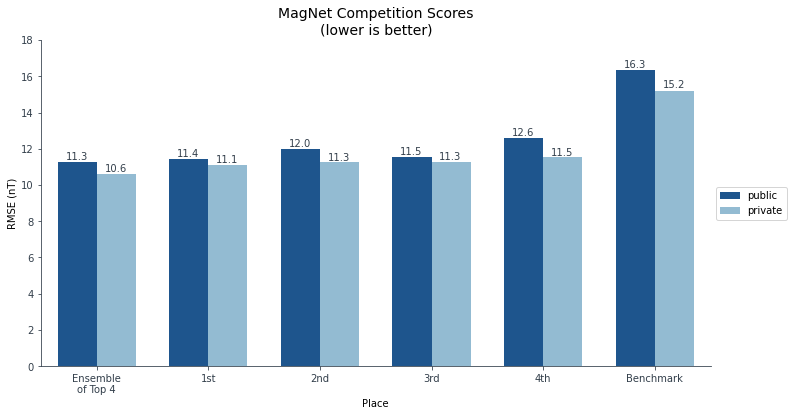


## 8. New Features

Testing newly engineered features such as **dynamic speed**, **electric field**, **southward magnetic field (`south mean`)**, and **magnetic field magnitude (`B`)** to evaluate their impact on Dst prediction performance.


### Creating New Features

In [ ]:
# reset features
Cols = ['speed_mean_1h', 'speed_mean_3h', 'speed_mean_6h', 'speed_mean_12h',
       'speed_mean_24h', 'density_mean_1h', 'density_mean_3h',
       'density_mean_6h', 'density_mean_12h', 'density_mean_24h',
       'temperature_mean_1h', 'temperature_mean_3h', 'temperature_mean_6h',
       'temperature_mean_12h', 'temperature_mean_24h', 'bt_mean_1h',
       'bt_mean_3h', 'bt_mean_6h', 'bt_mean_12h', 'bt_mean_24h',
       'speed_lag_1h', 'speed_lag_3h', 'speed_lag_6h', 'speed_lag_12h',
       'speed_lag_24h', 'density_lag_1h', 'density_lag_3h', 'density_lag_6h',
       'density_lag_12h', 'density_lag_24h', 'temperature_lag_1h',
       'temperature_lag_3h', 'temperature_lag_6h', 'temperature_lag_12h',
       'temperature_lag_24h', 'bt_lag_1h', 'bt_lag_3h', 'bt_lag_6h',
       'bt_lag_12h', 'bt_lag_24h', 'bx_gsm_mean_1h', 'bx_gsm_mean_3h',
       'bx_gsm_mean_6h', 'bx_gsm_mean_12h', 'bx_gsm_mean_24h',
       'by_gsm_mean_1h', 'by_gsm_mean_3h', 'by_gsm_mean_6h', 'by_gsm_mean_12h',
       'by_gsm_mean_24h', 'bz_gsm_mean_1h', 'bz_gsm_mean_3h', 'bz_gsm_mean_6h',
       'bz_gsm_mean_12h', 'bz_gsm_mean_24h', 'gse_x_ace', 'gse_y_ace',
       'gse_z_ace', 'gse_x_dscovr', 'gse_y_dscovr', 'gse_z_dscovr',
       'smoothed_ssn', "dst", "dst_future"]
features = features[Cols]
features_test = features_test[Cols]

In [ ]:
def create_features(feature):
    for i in [1, 3, 6, 12, 24]:
          # feature[f'dynamic_pressure_mean_{i}h'] = 0.5 * feature[f'density_mean_{i}h'] * feature[f'speed_mean_{i}h']**2
          # feature[f'electric_field_mean_{i}h'] = feature[f'speed_mean_{i}h'] * np.abs(feature[f'bz_gsm_mean_{i}h'])
          feature[f'bz_south_mean_{i}h'] = np.maximum(-feature[f'bz_gsm_mean_{i}h'], 0)
          feature[f'bmag_mean_{i}h'] = np.sqrt(
    feature[f'bx_gsm_mean_{i}h']**2 +
    feature[f'by_gsm_mean_{i}h']**2 +
    feature[f'bz_gsm_mean_{i}h']**2)

In [ ]:
create_features(features)

In [ ]:
create_features(features_test)

In [ ]:
features_test.filter(regex='bmag_mean|bz_south').head()

bz_south_mean_1h  bmag_mean_1h  bz_south_mean_3h  \
period timedelta                                                           
test_a 0 days 00:00:00          0.000000      4.912250          0.000000   
       0 days 01:00:00          0.000000      4.765041          0.000000   
       0 days 02:00:00          1.761833      5.040478          0.614959   
       0 days 03:00:00          0.000000      5.478823          0.181556   
       0 days 04:00:00          0.000000      6.056453          0.000000   

                        bmag_mean_3h  bz_south_mean_6h  bmag_mean_6h  \
period timedelta                                                       
test_a 0 days 00:00:00      4.912250          0.000000      4.912250   
       0 days 01:00:00      4.767029          0.000000      4.767029   
       0 days 02:00:00      4.769743          0.614959      4.769743   
       0 days 03:00:00      4.952479          0.179779      4.951920   
       0 days 04:00:00      5.345860          0.000000      5.185051   

                        bz_south_mean_12h  bmag_mean_12h  bz_south_mean_24h  \
period timedelta                                                              
test_a 0 days 00:00:00           0.000000       4.912250           0.000000   
       0 days 01:00:00           0.000000       4.767029           0.000000   
       0 days 02:00:00           0.614959       4.769743           0.614959   
       0 days 03:00:00           0.179779       4.951920           0.179779   
       0 days 04:00:00           0.000000       5.185051           0.000000   

                        bmag_mean_24h  
period timedelta                       
test_a 0 days 00:00:00       4.912250  
       0 days 01:00:00       4.767029  
       0 days 02:00:00       4.769743  
       0 days 03:00:00       4.951920  
       0 days 04:00:00       5.185051

### Testing New Features

In [ ]:
def split_df():
  train_parts = []
  val_parts = []

  for period, df_period in features.groupby(level='period'):
      train_p, val_p = train_test_split(
          df_period,
          test_size=0.2,
          shuffle=False
      )

      train_parts.append(train_p)
      val_parts.append(val_p)
  train_df = pd.concat(train_parts)
  val_df = pd.concat(val_parts)
  return train_df, val_df

In [ ]:
def split_data(train_df, val_df, features_test):
  X_train = train_df.drop(columns=["dst", "dst_future"])
  y_train = train_df[["dst", "dst_future"]]
  X_val = val_df.drop(columns=["dst", "dst_future"])
  y_val = val_df[["dst", "dst_future"]]
  X_test = features_test.drop(columns=["dst", "dst_future"])
  y_test = features_test[["dst", "dst_future"]]
  return X_train, y_train, X_val, y_val, X_test, y_test, train_df, val_df


In [ ]:
def evaluate(model):
    train_preds = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_preds = model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    estimate_rank(model)
    print(f"\nTrain RMSE: {train_rmse:.4f}\t\t\tVal RMSE: {val_rmse:.4f}")

In [ ]:
train_df, val_df = split_df()

In [ ]:
(X_train, y_train,
X_val, y_val,
X_test, y_test,
train_df, val_df) = split_data(train_df, val_df, features_test)

In [ ]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
features.shape, features_test.shape

((139872, 74), (59184, 74))

In [ ]:
X_train.shape, X_val.shape, X_test.shape

((111897, 72), (27975, 72), (59184, 72))

In [ ]:
evaluate(linear_model)

Your RMSE: 14.0864
Rank : 36 / 85
Percentile: 57.65%
Gap to #1: 2.9553
Best: 11.1311, Worst: 46.9243

Train RMSE: 11.5924			Val RMSE: 11.1971


#### Observations

* Individual geomagnetic features generally improved performance (**except dynamic speed**). The largest gain came from the magnetic field magnitude (`B`), reducing the test score from **14.75** to **14.35**.

* `Electric field`, `southward Bz` (`south mean`), and `B` each improved validation loss; however, combining multiple engineered features did not consistently improve the leaderboard score, suggesting feature redundancy or overfitting.

* The best result was obtained using **`B` and southward Bz together** (**test score = 14.09**), while adding additional features such as **dynamic speed** and **electric field** further reduced validation loss but did not translate into better test performance.


#### Conclusion

• Magnetic field–based features are the most informative additions for Dst prediction in the current linear model.

• Lower training and validation losses do not necessarily lead to better leaderboard performance; external generalization remains the key metric.

• Future feature engineering should focus on selective, physically meaningful features rather than combining all available derived variables.

### Save Intermediate DataFrames


In [ ]:
train_df.to_parquet('train_df.parquet')
val_df.to_parquet('val_df.parquet')
features_test.to_parquet('features_test.parquet')

In [ ]:
import pandas as pd
train_df = pd.read_parquet('train_df.parquet')
val_df = pd.read_parquet('val_df.parquet')
features_test = pd.read_parquet('features_test.parquet')

## 9. Train & Evaluate Different Models
- Linear Regression
- Random Forest
- Gradient Boosting

In [ ]:
(X_train, y_train,
X_val, y_val,
X_test, y_test,
train_df, val_df) = split_data(train_df, val_df, features_test)

In [ ]:
X_train.shape, X_val.shape, X_test.shape

((111897, 72), (27975, 72), (59184, 72))

### Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Ridge(random_state=42,)

In [ ]:
%%time
ridge_model.fit(X_train, y_train)

CPU times: user 116 ms, sys: 0 ns, total: 116 ms
Wall time: 79 ms


Ridge(random_state=42)

In [ ]:
evaluate(ridge_model)

Your RMSE: 14.0864
Rank : 36 / 85
Percentile: 57.65%
Gap to #1: 2.9553
Best: 11.1311, Worst: 46.9243

Train RMSE: 11.5924			Val RMSE: 11.1971


### Random Forest

In [ ]:
def train_percent(X_train, frac=0.01):
    sampled = []

    for period, df_period in X_train.groupby(level='period'):
        n = int(len(df_period) * frac)
        sampled.append(df_period.iloc[:n])

    return pd.concat(sampled)

# using only 5% of training Data
X_train_sample = train_percent(X_train, .05)
y_train_sample = y_train.loc[X_train_sample.index]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_sample, y_train_sample)

RandomForestRegressor(random_state=42)

In [ ]:
evaluate(model)

Your RMSE: 19.1448
Rank : 73 / 85
Percentile: 14.12%
Gap to #1: 8.0137
Best: 11.1311, Worst: 46.9243

Train RMSE: 20.1024			Val RMSE: 19.8035


### Gradient Boosting

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=.025,
    device="cuda",
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:18.55582
[100]	validation_0-rmse:11.76484
[200]	validation_0-rmse:10.75246
[300]	validation_0-rmse:10.45468
[400]	validation_0-rmse:10.27251
[500]	validation_0-rmse:10.14994
[600]	validation_0-rmse:10.06061
[700]	validation_0-rmse:10.01153
[800]	validation_0-rmse:9.98456
[900]	validation_0-rmse:9.95187
[999]	validation_0-rmse:9.91742


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.025, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate(model)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning:

[13:13:41] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.




Your RMSE: 14.0209
Rank : 35 / 85
Percentile: 58.82%
Gap to #1: 2.8898
Best: 11.1311, Worst: 46.9243

Train RMSE: 7.4562			Val RMSE: 9.9174


### Observations

* **Linear Regression** and **Ridge Regression** produced identical results, suggesting regularization had minimal impact on the selected features.

* **Random Forest** showed weaker generalization and required significantly longer training time, therefore further experimentation with it was omitted from the notebook.

* **XGBoost** achieved lower training and validation losses than the other models, making it the preferred model for further optimization.

* Lower training loss did not always lead to better test performance, highlighting the importance of evaluating generalization.


## 10. Tune Hyperparameters

Defining a helper function to efficiently tune and evaluate different hyperparameter combinations for model optimization.


In [ ]:
import matplotlib.pyplot as plt

def test_params(ModelClass, **params):
    model = ModelClass(**params).fit(X_train, y_train)
    train_rmse = mean_squared_error(model.predict(X_train), y_train)**.5
    val_rmse = mean_squared_error(model.predict(X_val), y_val)**.5
    return train_rmse, val_rmse

def test_param_and_plot(ModelClass, param_name, param_values, **other_params):
    train_errors, val_errors = [], []
    for value in param_values:
        params = dict(other_params)
        params[param_name] = value
        train_rmse, val_rmse = test_params(ModelClass, **params)
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)

    plt.figure(figsize=(10,6))
    plt.title('Overfitting curve: ' + param_name)
    plt.plot(param_values, train_errors, 'b-o')
    plt.plot(param_values, val_errors, 'r-o')
    plt.xlabel(param_name)
    plt.ylabel('RMSE')
    plt.legend(['Training', 'Validation'])

In [ ]:
best_params = {
    "max_depth": 4,
    "learning_rate": .025,
    "device": "cuda",
    "random_state": 42
}

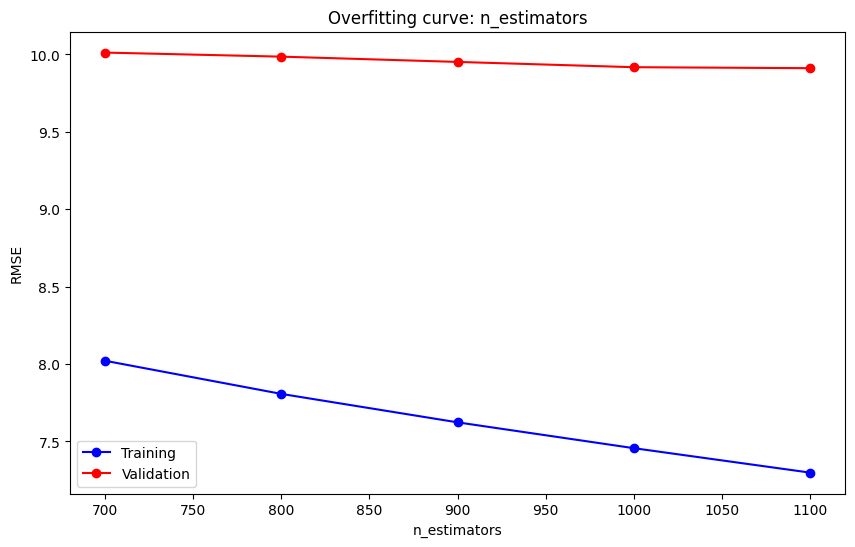

In [ ]:
test_param_and_plot(XGBRegressor, 'n_estimators', [ 700, 800, 900, 1000, 1100], **best_params)

* `n_estimators = 900` is selected after testing values from **700 to 1100**, as it provided the best balance between model performance and generalization among the evaluated values.


In [ ]:
model= XGBRegressor(
    n_estimators=900,
    max_depth=4,
    learning_rate=.025,
    device="cuda",
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.025, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate(model)

Your RMSE: 14.0003
Rank : 35 / 85
Percentile: 58.82%
Gap to #1: 2.8692
Best: 11.1311, Worst: 46.9243

Train RMSE: 7.6229			Val RMSE: 9.9515


* After tuning `n_estimators`, the model performance improved slightly, reducing the test RMSE from **14.0209** to **14.0003** while maintaining the estimated leaderboard rank of **#35**.


In [ ]:
best_params = {
    "n_estimators": 900,
    "learning_rate": .025,
    "device": "cuda",
    "random_state": 42
}

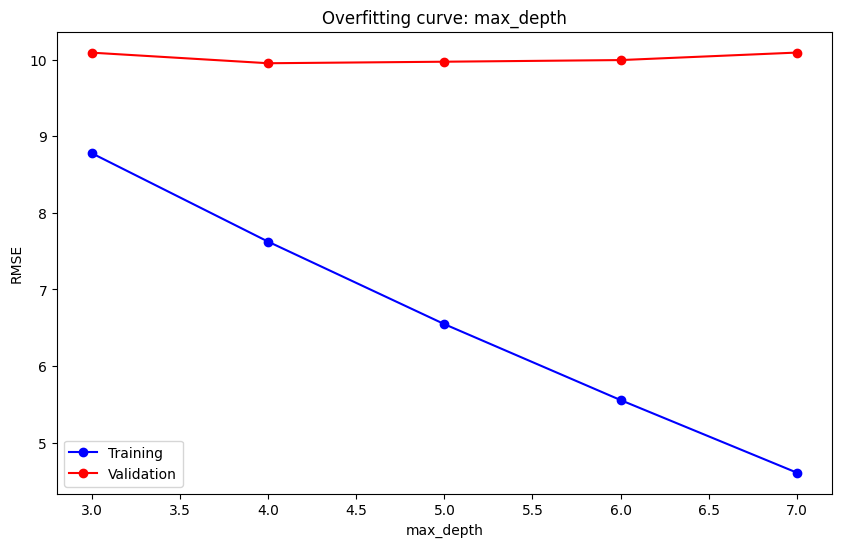

In [ ]:
test_param_and_plot(XGBRegressor, 'max_depth', [3, 4, 5, 6, 7], **best_params)

* `max_depth = 4` is selected as it achieved the lowest validation loss among the tested values and performed best overall, while higher depth values showed signs of overfitting without improving performance.


In [ ]:
model = XGBRegressor(
    n_estimators=900,
    max_depth=4,
    learning_rate=.025,
    device="cuda",
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.025, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate(model)

Your RMSE: 14.0003
Rank : 35 / 85
Percentile: 58.82%
Gap to #1: 2.8692
Best: 11.1311, Worst: 46.9243

Train RMSE: 7.6229			Val RMSE: 9.9515


* After tuning `max_depth`, the model performance remained similar while using a simpler and more generalized model.


In [ ]:
best_params = {
    "n_estimators": 900,
    "max_depth": 4,
    "device": "cuda",
    "random_state": 42
}

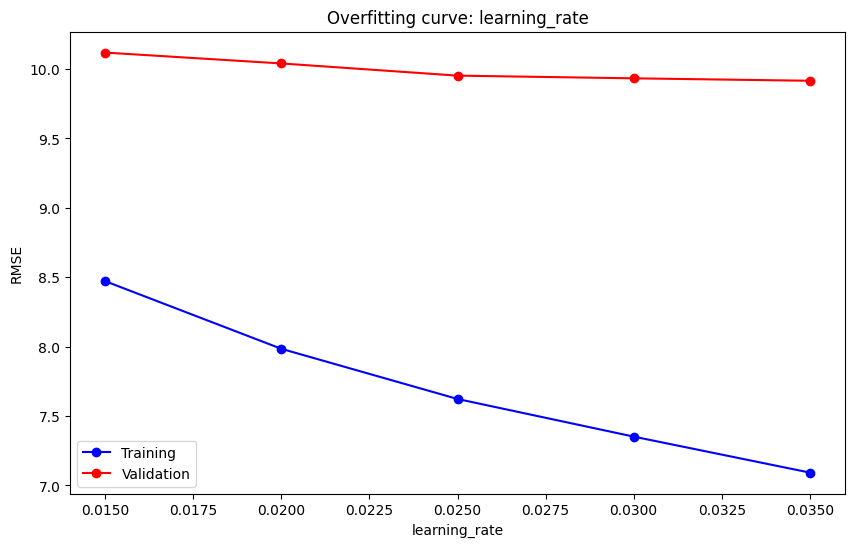

In [ ]:
test_param_and_plot(XGBRegressor, 'learning_rate', [.015, .02, .025, .03, .035], **best_params)

* `learning_rate = 0.02` is selected after testing values **0.015 to 0.035**. Although values from **0.025 to 0.035** produced slightly lower validation loss, `0.02` provided the best balance between overall model performance and generalization.


In [ ]:
model = XGBRegressor(
    n_estimators=900,
    max_depth=4,
    learning_rate=.02,
    device="cuda",
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate(model)

Your RMSE: 13.9804
Rank : 35 / 85
Percentile: 58.82%
Gap to #1: 2.8493
Best: 11.1311, Worst: 46.9243

Train RMSE: 7.9842			Val RMSE: 10.0392


* After tuning `learning_rate`, the model performance improved slightly, reducing the test RMSE from **14.0003** to **13.9804** while maintaining the estimated leaderboard rank of **#35**.


In [ ]:
best_params = {
    "n_estimators": 900,
    "max_depth": 4,
    "learning_rate": .02,
    "device": "cuda",
    "random_state": 0
}

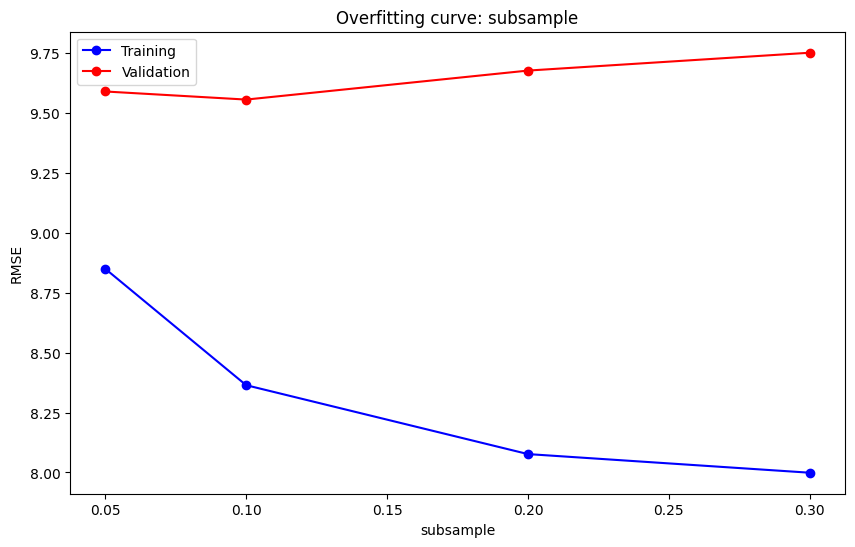

In [ ]:
test_param_and_plot(XGBRegressor, 'subsample', [.05, .1, .2, .3], **best_params)

* `subsample = 0.1` is selected after testing values **0.05, 0.1, 0.2, and 0.3**, as it provided the best balance between model generalization and predictive performance while achieving the minimum validation loss.


In [ ]:
model = XGBRegressor(
    n_estimators=900,
    max_depth=4,
    learning_rate=.02,
    subsample=.1,
    device="cuda",
    random_state=0
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate(model)

Your RMSE: 13.6934
Rank : 31 / 85
Percentile: 63.53%
Gap to #1: 2.5623
Best: 11.1311, Worst: 46.9243

Train RMSE: 8.3641			Val RMSE: 9.5564


* After tuning `subsample`, the model performance improved further, reducing the test RMSE from **13.9804** to **13.6934** and improving the estimated leaderboard rank from **#35** to **#31**.


#### Final Conclusion

The project successfully developed a machine learning pipeline for **Dst prediction** using real-time solar wind observations and feature engineering.

Several engineered features and hyperparameters were tested iteratively to improve model performance while maintaining generalization. Among the tested approaches, careful feature selection and tuning of **`n_estimators`**, **`max_depth`**, **`learning_rate`**, and **`subsample`** resulted in consistent improvements.

The final tuned **XGBoost** model achieved:

* **Test RMSE:** **13.6934**
* **Estimated Leaderboard Rank:** **#31 / 85**
* **Percentile:** **63.53%**

The results outperform the competition benchmark and demonstrate that combining domain-inspired feature engineering with systematic hyperparameter tuning can improve geomagnetic storm forecasting performance.

#### Future Work

Further improvements can be explored by:

* Investigating currently unexplored columns and their relationship with Dst.
* Training using a smaller subset of highly informative features and removing low-impact features.
* Designing additional physically meaningful engineered features.
* Exploring more advanced models and ensemble approaches.
* Testing different feature selection and temporal aggregation strategies to further improve generalization.
